# Case Closed — Node-Level Suspect Prediction (GNN project) — v5

## 1. Problem framing

Node-level classification: each case is one graph (persons/locations/objects/clues). Classify person nodes tagged `suspect` as murderer vs. not. Per-graph softmax over each case's suspect set, trained with per-graph cross-entropy (exactly one murderer per case).

Domain: whodunit reasoning over structured *Case Closed* episode data. Dataset: `cases_v3` (loader: `case_closed_dataset.py`), one graph per case.

## 2. Dataset understanding & audit

Load → schema → per-case stats → corpus rundown → suspects-per-case → role distribution → edge catalogue → example case → leak audit → cleaned-dataset export.

In [1]:
# --- load data --------------------------------------------------------
import sys, os, math, json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# this notebook lives in Reo analysis/v5/, two levels below the project root
# (Reo analysis/v5/ -> Reo analysis/ -> 2.0/), unlike v1-v4 which sat one
# level up -- case_closed_dataset.py / visualize_case.py live in 2.0/.
PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)
from case_closed_dataset import list_case_files, load_case, _edge_relation_key

DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "case_closed_dataset", "cases_v3")
files = list_case_files(DATA_ROOT)
all_cases = [load_case(f) for f in files]
print(f"{len(all_cases)} cases loaded from {DATA_ROOT}")


247 cases loaded from /home/reo/Faks/GNN/2.0/data/case_closed_dataset/cases_v3


In [2]:
# --- drop single-suspect cases -----------------------------------------
# A "case" = one episode = one graph. A "suspect" = a person node whose
# `roles` list contains "suspect" (as opposed to e.g. "witness" or
# "victim") -- these are the candidates the softmax head chooses between.
# A case with exactly 1 suspect has no real choice to make (accuracy is
# trivially 100%), so it adds noise to metrics without adding signal.
# Dropped here, once, so every cell below already works on the clean corpus.
def n_suspects(case):
    return sum(1 for p in case["nodes"]["persons"] if "suspect" in p.get("roles", []))

single_suspect_cases = [c["case_id"] for c in all_cases if n_suspects(c) == 1]
cases = [c for c in all_cases if n_suspects(c) > 1]

print(f"dropped {len(single_suspect_cases)} single-suspect cases, {len(cases)} remain")
print(single_suspect_cases)


dropped 10 single-suspect cases, 237 remain
['ep083_general_hospital_murder_case', 'ep148_the_streetcars_sudden_stopping_case', 'ep243-244_kogoro_mouris_imposter', 'ep658_the_hot_chocolate_trap', 'ep750_the_man_who_was_betrayed_by_the_sea', 'ep774_munchs_missing_scream', 'ep830-832_a_cottage_surrounded_by_zombies', 'ep840_the_last_gift', 'ep872-874_conan_and_heijis_nue_legend', 'ep907_the_j_league_bodyguard']


### Schema map

Case JSON structure, checked programmatically against every file in the corpus.

In [3]:
# --- schema map ----------------------------------------------------------
schema_versions = Counter(c.get("schema_version") for c in cases)
node_collections = Counter()
for c in cases:
    node_collections.update(c["nodes"].keys())

print("schema_version across corpus:", dict(schema_versions))
print("node collections present in every case:", dict(node_collections))
print("""
Nodes  = persons | locations | objects | clues   (heterogeneous, 4 types)
         persons:   id, name, aliases, roles[], occupation, attrs{}
         locations: id, name, attrs{}
         objects:   id, name, role, attrs{}
         clues:     id, desc, clue_type
Edges  = {type, from, to, order?, ...}            (directed, multigraph)
         'relationship' edges carry an extra relation_type (e.g. 'classmate')
Label  = {murderer_id: <one person id>}           (exactly one per case)
""")


schema_version across corpus: {'v3': 237}
node collections present in every case: {'persons': 237, 'locations': 237, 'objects': 237, 'clues': 237}

Nodes  = persons | locations | objects | clues   (heterogeneous, 4 types)
         persons:   id, name, aliases, roles[], occupation, attrs{}
         locations: id, name, attrs{}
         objects:   id, name, role, attrs{}
         clues:     id, desc, clue_type
Edges  = {type, from, to, order?, ...}            (directed, multigraph)
         'relationship' edges carry an extra relation_type (e.g. 'classmate')
Label  = {murderer_id: <one person id>}           (exactly one per case)



### Per-case stats

Per-case node/edge counts and average degree (`avg_degree = 2E / N`).

In [4]:
# --- per-case stats table -------------------------------------------------
rows = []
for c in cases:
    persons = c["nodes"]["persons"]
    n_locs, n_objs, n_clues = (len(c["nodes"][k]) for k in ("locations", "objects", "clues"))
    n_nodes = len(persons) + n_locs + n_objs + n_clues
    n_edges = len(c["edges"])
    rows.append(dict(
        case_id=c["case_id"], n_persons=len(persons), n_suspects=n_suspects(c),
        n_locations=n_locs, n_objects=n_objs, n_clues=n_clues,
        n_nodes=n_nodes, n_edges=n_edges, avg_degree=2 * n_edges / n_nodes,
    ))
stats = pd.DataFrame(rows)
stats.describe().loc[["mean", "min", "max"]]


,n_persons,n_suspects,n_locations,n_objects,n_clues,n_nodes,n_edges,avg_degree
mean,6.468354,3.421941,4.472574,6.64557,2.85654,20.443038,48.223629,4.720397
min,3.000000,2.000000,1.000000,1.00000,0.00000,10.000000,23.000000,2.960000
max,17.000000,8.000000,12.000000,13.00000,7.00000,37.000000,130.000000,7.379310


### Dataset rundown

Corpus totals: node types, node counts per type, edge count, average degree.

In [5]:
# --- rundown: node types & corpus totals ----------------------------------
NODE_TYPES = ["persons", "locations", "objects", "clues"]
node_type_totals = {t: int(stats[f"n_{t}"].sum()) for t in NODE_TYPES}

print(f"cases: {len(cases)}")
print(f"node types: {len(NODE_TYPES)}  {NODE_TYPES}")
for t, n in node_type_totals.items():
    print(f"  {t:12s} {n:5d} total   ({n / len(cases):.2f} / case)")
print(f"nodes total: {sum(node_type_totals.values())}   edges total: {int(stats['n_edges'].sum())}")
print(f"avg degree (corpus-wide 2E/N): {2 * stats['n_edges'].sum() / stats['n_nodes'].sum():.3f}")


cases: 237
node types: 4  ['persons', 'locations', 'objects', 'clues']
  persons       1533 total   (6.47 / case)
  locations     1060 total   (4.47 / case)
  objects       1575 total   (6.65 / case)
  clues          677 total   (2.86 / case)
nodes total: 4845   edges total: 11429
avg degree (corpus-wide 2E/N): 4.718


### Suspects per case (softmax candidate-pool size)

Distribution of suspect count per case. Sets the per-case random-guess floor and is the stratification variable for the train/val/test split.

In [6]:
# --- suspects per case: distribution & class ratio (distribucija labela, omjer klasa) ---
n_cases = len(cases)
total_suspects = int(stats["n_suspects"].sum())

print(f"suspects/case: mean={stats['n_suspects'].mean():.2f}  "
      f"min={stats['n_suspects'].min()}  max={stats['n_suspects'].max()}")
print(f"suspects/case distribution: {sorted(stats['n_suspects'].value_counts().to_dict().items())}")
print(f"\nsuspect nodes total (softmax candidate pool, all cases): {total_suspects}")
print(f"  positives (the murderer): {n_cases}")
print(f"  negatives (other suspects): {total_suspects - n_cases}")
print(f"per-graph softmax baseline (avg of 1/n_suspects): {np.mean(1 / stats['n_suspects']):.3f}")
print(f"pooled-binary positive rate (murderer / all suspect nodes): {n_cases / total_suspects:.3f}")


suspects/case: mean=3.42  min=2  max=8
suspects/case distribution: [(2, 30), (3, 114), (4, 65), (5, 23), (6, 2), (7, 2), (8, 1)]

suspect nodes total (softmax candidate pool, all cases): 811
  positives (the murderer): 237
  negatives (other suspects): 574
per-graph softmax baseline (avg of 1/n_suspects): 0.315
pooled-binary positive rate (murderer / all suspect nodes): 0.292


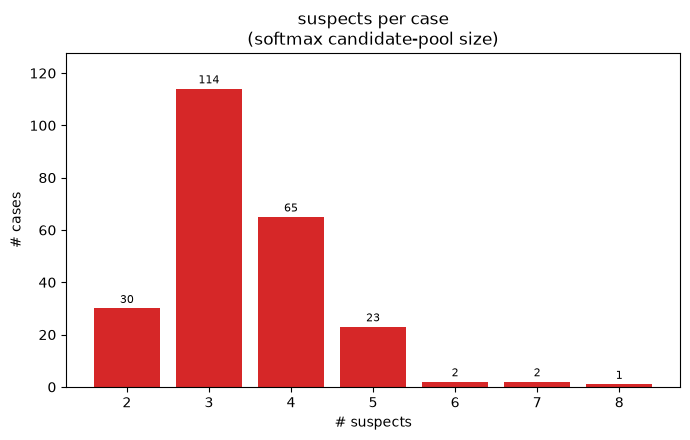

In [7]:
# --- viz: suspects per case (softmax candidate-pool size) ------------------
sc = stats["n_suspects"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(sc.index, sc.values, color="tab:red")
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_title("suspects per case\n(softmax candidate-pool size)")
ax.set_xlabel("# suspects"); ax.set_ylabel("# cases")
ax.set_xticks(sc.index)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()


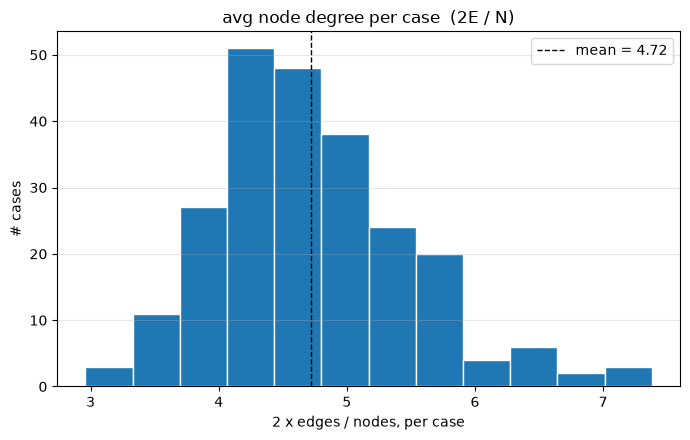

In [8]:
# --- viz: avg node degree per case (2E / N) ---------------------------------
mean_deg = stats["avg_degree"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(stats["avg_degree"], bins=12, color="tab:blue", edgecolor="white")
ax.axvline(mean_deg, color="black", linestyle="--", linewidth=1, label=f"mean = {mean_deg:.2f}")
ax.set_title("avg node degree per case  (2E / N)")
ax.set_xlabel("2 x edges / nodes, per case"); ax.set_ylabel("# cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Person role distribution

Roles are multi-hot — a person can hold more than one (e.g. `victim` + `backstory_figure`).

In [9]:
# --- person role distribution ---------------------------------------------
role_counter = Counter()
for c in cases:
    for p in c["nodes"]["persons"]:
        role_counter.update(p.get("roles", []))

for r, n in role_counter.most_common():
    print(f"  {r:18s} {n:4d}")


  suspect             811
  witness             404
  victim              384
  backstory_figure    264
  bystander            85
  client                1
  investigator          1


### Edge catalogue

Raw `type` values vs. collapsed keys (`_edge_relation_key` folds every `relationship` sub-type into one `relationship` key).

In [10]:
# --- edge catalogue: raw types vs relation_type sub-types ------------------
edge_type_counter = Counter()
relation_type_counter = Counter()
for c in cases:
    for e in c["edges"]:
        edge_type_counter[e["type"]] += 1
        if e.get("relation_type"):
            relation_type_counter[e["relation_type"]] += 1

n_singleton_types = sum(1 for v in edge_type_counter.values() if v == 1)
collapsed_universe = len(edge_type_counter) - 1 + 1  # drop raw "relationship", add back one flat key

print(f"unique raw edge 'type' verbs: {len(edge_type_counter)}  "
      f"({n_singleton_types} appear in only 1 edge -- long tail)")
print(f"unique relation_type values folded away (no longer separate vocab entries): {len(relation_type_counter)}")
print(f"collapsed key space ({len(edge_type_counter)} - 1 + 1): {collapsed_universe}")
print("\ntop 12 raw edge types by frequency:")
for t, n in edge_type_counter.most_common(12):
    print(f"  {t:22s} {n:5d}")


unique raw edge 'type' verbs: 623  (389 appear in only 1 edge -- long tail)
unique relation_type values folded away (no longer separate vocab entries): 271
collapsed key space (623 - 1 + 1): 623

top 12 raw edge types by frequency:
  was_at                  2990
  relationship            1343
  implicates              1323
  regarding               1294
  owns                     676
  has_motive_against       599
  located_in               464
  kills                    288
  leaves_evidence          271
  stages_alibi_using       210
  confronts                116
  steals                    73


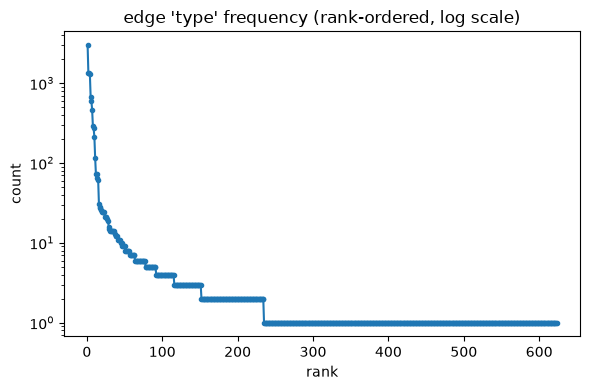

In [11]:
# --- viz: edge 'type' frequency long tail (log scale) ----------------------
freqs = sorted(edge_type_counter.values(), reverse=True)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(freqs) + 1), freqs, marker=".")
plt.yscale("log")
plt.title("edge 'type' frequency (rank-ordered, log scale)")
plt.xlabel("rank"); plt.ylabel("count")
plt.tight_layout()
plt.show()


### Example case: ep011 (Moonlight Sonata)

Suspects red, murderer labeled. Re-drawn after cleaning below for comparison.

case: Moonlight Sonata Murder Case
persons=12 suspects=8 locations=5 objects=8 clues=2 edges=98
murderer: Narumi Asai  (p8)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


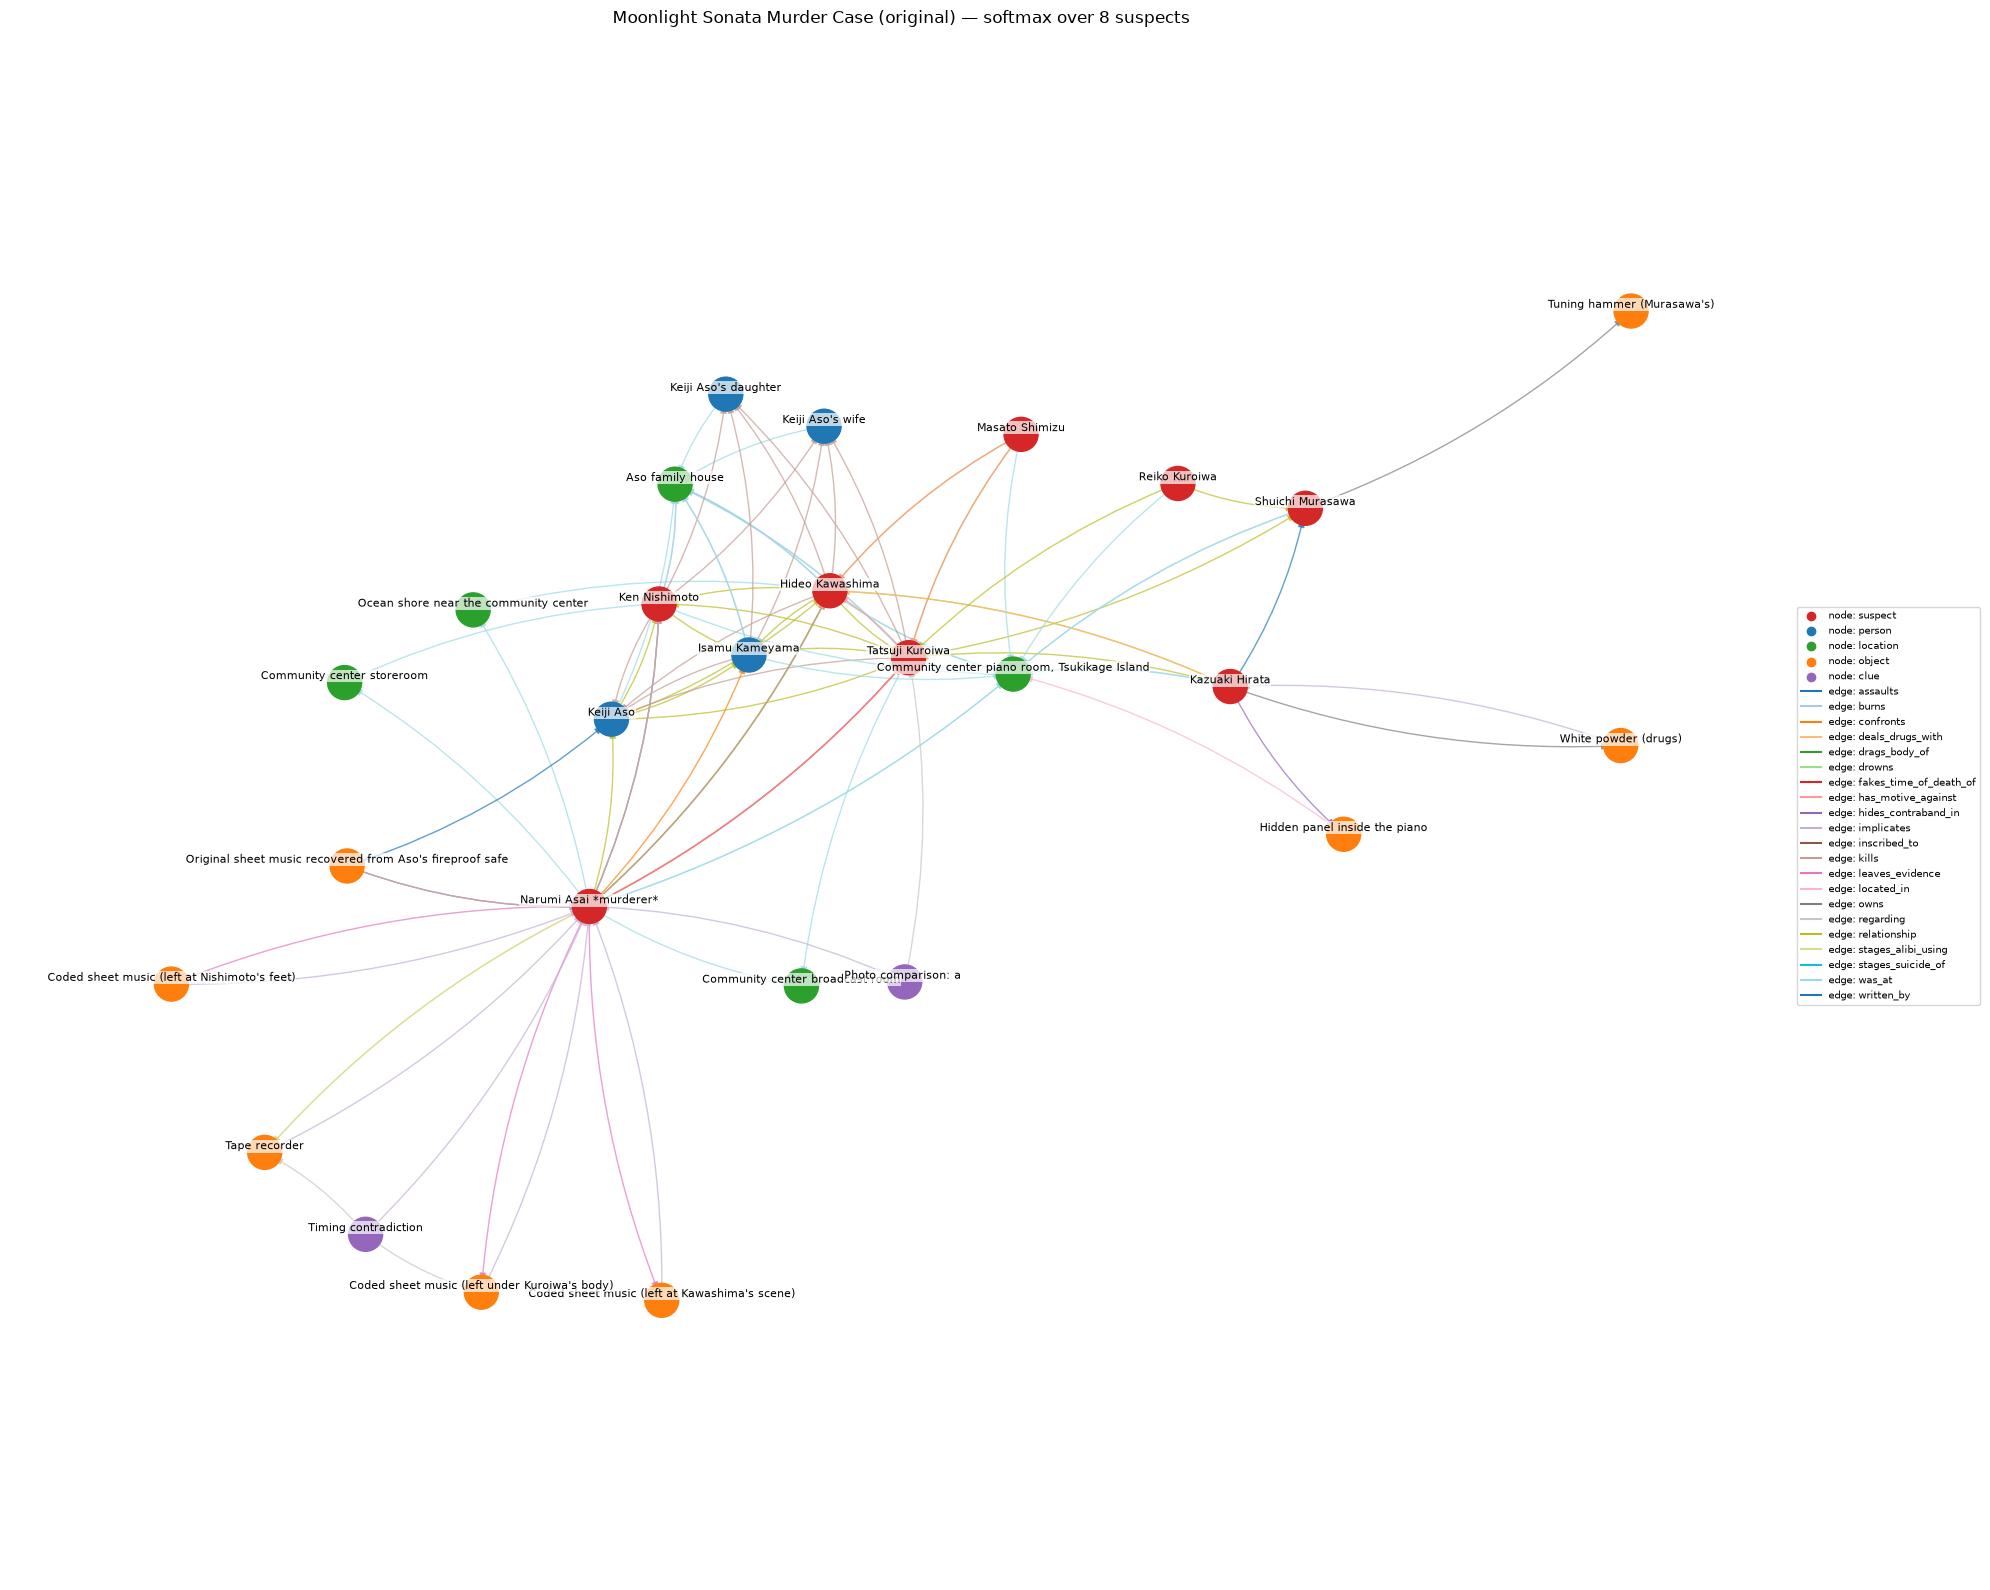

In [12]:
# --- visualize moonlight sonata (original) ----------------------------------
from visualize_case import load_case as load_case_for_viz, draw_case

example_path = os.path.join(DATA_ROOT, "ep011_moonlight_sonata_murder_case.json")
example = load_case_for_viz(example_path)

ex_persons = example["nodes"]["persons"]
ex_suspects = [p for p in ex_persons if "suspect" in p.get("roles", [])]
ex_murderer_id = example["label"]["murderer_id"]
ex_murderer = next(p for p in ex_persons if p["id"] == ex_murderer_id)

print(f"case: {example['title']}")
print(f"persons={len(ex_persons)} suspects={len(ex_suspects)} "
      f"locations={len(example['nodes']['locations'])} "
      f"objects={len(example['nodes']['objects'])} "
      f"clues={len(example['nodes']['clues'])} edges={len(example['edges'])}")
print(f"murderer: {ex_murderer['name']}  ({ex_murderer_id})")

draw_case(example, title=f"{example['title']} (original) — softmax over {len(ex_suspects)} suspects")


### Leak audit: which edge types give away the murderer?

```
concentration(key) = murderer_touches(key) / (murderer_touches(key) + other_suspect_touches(key))
```
Scored per edge key over suspect-touching instances, min support 10 murderer-touches. ~0.29 = base rate (no signal), → 1.0 = giveaway. Threshold: `action` keys ≥ 0.65 excluded. `relationship` exempt by category (pre-existing social fact, not post-hoc narration).

In [13]:
# --- leaks: compute per-key touch counts -----------------------------------
murderer_touch = Counter()          # key -> # cases where the murderer is touched
other_touch = Counter()             # key -> # (case, non-murderer-suspect) pairs touched
case_support = defaultdict(set)     # key -> set of case_ids where key touches ANY suspect

for c in cases:
    persons = c["nodes"]["persons"]
    suspect_ids = {p["id"] for p in persons if "suspect" in p.get("roles", [])}
    murderer_id = c["label"]["murderer_id"]
    other_ids = suspect_ids - {murderer_id}

    touched_by = defaultdict(set)   # key -> suspect ids touched, this case
    for e in c["edges"]:
        key = _edge_relation_key(e)   # 'kills', 'owns', ... or 'rel:classmate', ...
        for endpoint in (e["from"], e["to"]):
            if endpoint in suspect_ids:
                touched_by[key].add(endpoint)

    for key, ids in touched_by.items():
        case_support[key].add(c["case_id"])
        if murderer_id in ids:
            murderer_touch[key] += 1
        other_touch[key] += len(ids & other_ids)

print(f"{len(case_support)} distinct edge keys touch at least one suspect")


512 distinct edge keys touch at least one suspect


In [14]:
# --- leaks: concentration score + thresholding ------------------------------
MIN_MURDERER_SUPPORT = 10   # only score keys that touch the murderer in >=10 cases.
                             # (Verbs with fewer touches than this -- e.g. `strangles`,
                             # `orders` -- are reviewed manually below instead of being
                             # auto-flagged: at n<10 the concentration score is too noisy to
                             # threshold on its own -- see the manual-review section.)
EXCLUDE_THRESHOLD = 0.65    # action-verb edges >= this: confident post-hoc-narration leak

base_rate = n_cases / total_suspects  # reference line: "no signal" concentration

leak_rows = []
for key, cids in case_support.items():
    m, o = murderer_touch[key], other_touch[key]
    if m < MIN_MURDERER_SUPPORT:
        continue
    concentration = m / (m + o)
    leak_rows.append(dict(
        edge_key=key, category="relationship" if key == "relationship" else "action",
        support_cases=len(cids), murderer_touches=m, other_suspect_touches=o,
        murderer_rate=m / n_cases, other_suspect_rate=o / (total_suspects - n_cases),
        concentration=concentration,
    ))

leak_df = pd.DataFrame(leak_rows).sort_values("concentration", ascending=False).reset_index(drop=True)
print(f"base rate (murderers / all suspects): {base_rate:.3f}")
print(f"{len(leak_df)} edge keys with murderer support >= {MIN_MURDERER_SUPPORT}")
leak_df


base rate (murderers / all suspects): 0.292
29 edge keys with murderer support >= 10


,edge_key,category,support_cases,murderer_touches,other_suspect_touches,murderer_rate,other_suspect_rate,concentration
0,poisons,action,20,19,1,0.080169,0.001742,0.950000
1,stages_alibi_using,action,118,115,7,0.485232,0.012195,0.942623
2,drags_body_of,action,23,23,2,0.097046,0.003484,0.920000
3,wears,action,11,10,1,0.042194,0.001742,0.909091
4,uses,action,41,39,4,0.164557,0.006969,0.906977
5,hides_contraband_in,action,18,16,2,0.067511,0.003484,0.888889
6,kills,action,192,191,25,0.805907,0.043554,0.884259
7,drugs,action,14,14,2,0.059072,0.003484,0.875000
8,leaves_evidence,action,128,125,19,0.527426,0.033101,0.868056
9,stages_suicide_of,action,26,25,4,0.105485,0.006969,0.862069


In [15]:
# --- leaks: which keys cross the 0.65 threshold -----------------------------
over_threshold = (leak_df["category"] == "action") & (leak_df["concentration"] >= EXCLUDE_THRESHOLD)
exclude_list = leak_df[over_threshold]

print(f"{len(exclude_list)} of {len(leak_df)} edge keys are >= {EXCLUDE_THRESHOLD} concentration")
leak_df


19 of 29 edge keys are >= 0.65 concentration


,edge_key,category,support_cases,murderer_touches,other_suspect_touches,murderer_rate,other_suspect_rate,concentration
0,poisons,action,20,19,1,0.080169,0.001742,0.950000
1,stages_alibi_using,action,118,115,7,0.485232,0.012195,0.942623
2,drags_body_of,action,23,23,2,0.097046,0.003484,0.920000
3,wears,action,11,10,1,0.042194,0.001742,0.909091
4,uses,action,41,39,4,0.164557,0.006969,0.906977
5,hides_contraband_in,action,18,16,2,0.067511,0.003484,0.888889
6,kills,action,192,191,25,0.805907,0.043554,0.884259
7,drugs,action,14,14,2,0.059072,0.003484,0.875000
8,leaves_evidence,action,128,125,19,0.527426,0.033101,0.868056
9,stages_suicide_of,action,26,25,4,0.105485,0.006969,0.862069


### Manual review: leaks below the automatic support gate

Verbs with < 10 murderer-touches, checked by hand instead of auto-thresholded. Added: `stabs, drowns, strangles, wields, conceals, discards, destroys_evidence, conceals_evidence_using, disposes_of, plants, disguises_as, forges, rigs, relocates, stages_accident_of, inscribed_to, confesses_to, installs, arrests, surrenders, exonerates`.

In [16]:
MANUAL_EXCLUDE = {
    "rigs", "disposes_of", "drowns", "plants", "confesses_to",
    "stages_accident_of", "destroys_evidence", "conceals_evidence_using",
    "conceals", "strangles", "installs", "wields", "stabs", "discards",
    "inscribed_to", "forges", "disguises_as", "relocates",
    "arrests", "surrenders", "exonerates",
}
print(f"{len(MANUAL_EXCLUDE)} manually-added edge types")


21 manually-added edge types


### Remove leaked edge types, export cleaned dataset

Every EXCLUDE-tier edge type dropped corpus-wide (nodes untouched). Output: `cases_v4`.

In [17]:
# --- remove all edges of every EXCLUDE-tier type, corpus-wide --------------
EXCLUDED_KEYS = set(exclude_list["edge_key"]) | MANUAL_EXCLUDE

removed_edge_counts = Counter()   # key -> # edges removed, corpus-wide
cleaned_cases = []
for c in cases:
    kept_edges = []
    for e in c["edges"]:
        key = _edge_relation_key(e)
        if key in EXCLUDED_KEYS:
            removed_edge_counts[key] += 1
        else:
            kept_edges.append(e)
    cleaned = dict(c)          # shallow copy: only "edges" changes below
    cleaned["edges"] = kept_edges
    cleaned["schema_version"] = "v4"
    cleaned_cases.append(cleaned)

total_removed = sum(removed_edge_counts.values())
total_kept = sum(len(c["edges"]) for c in cleaned_cases)
total_original = total_removed + total_kept

print(f"removing {len(EXCLUDED_KEYS)} edge types: {sorted(EXCLUDED_KEYS)}")
print(f"\nremoved {total_removed} edges corpus-wide, {total_kept} remain "
      f"({total_removed / total_original:.1%} of all {total_original} edges)")


removing 40 edge types: ['arrests', 'burns', 'conceals', 'conceals_evidence_using', 'confesses_to', 'destroys_evidence', 'discards', 'disguises_as', 'disposes_of', 'drags_body_of', 'drowns', 'drugs', 'exonerates', 'fakes_time_of_death_of', 'forges', 'hides_contraband_in', 'impersonates', 'implicates', 'inscribed_to', 'installs', 'kills', 'leaves_evidence', 'lures', 'plants', 'poisons', 'relocates', 'rigs', 'sabotages', 'stabs', 'stages_accident_of', 'stages_alibi_using', 'stages_suicide_of', 'steals', 'strangles', 'surrenders', 'tampers_with', 'uses', 'wears', 'wields', 'written_by']

removed 2714 edges corpus-wide, 8715 remain (23.7% of all 11429 edges)


In [18]:
# --- write the cleaned cases_v4 dataset -------------------------------------
OUT_DIR = os.path.join(os.getcwd(), "cases_v4")
os.makedirs(OUT_DIR, exist_ok=True)

for cleaned in cleaned_cases:
    out_path = os.path.join(OUT_DIR, f"{cleaned['case_id']}.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(cleaned, f, indent=2, ensure_ascii=False)

print(f"wrote {len(cleaned_cases)} cleaned case files to {OUT_DIR}")
print(f"(single-suspect cases dropped earlier are not included: {len(single_suspect_cases)} fewer files than the raw cases_v3 corpus)")


wrote 237 cleaned case files to /home/reo/Faks/GNN/2.0/Reo analysis/v5/cases_v4
(single-suspect cases dropped earlier are not included: 10 fewer files than the raw cases_v3 corpus)


### Moonlight Sonata, after cleaning

Same case, drawn from `cleaned_cases`.

case: Moonlight Sonata Murder Case
edges before cleaning: 98   after: 60


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


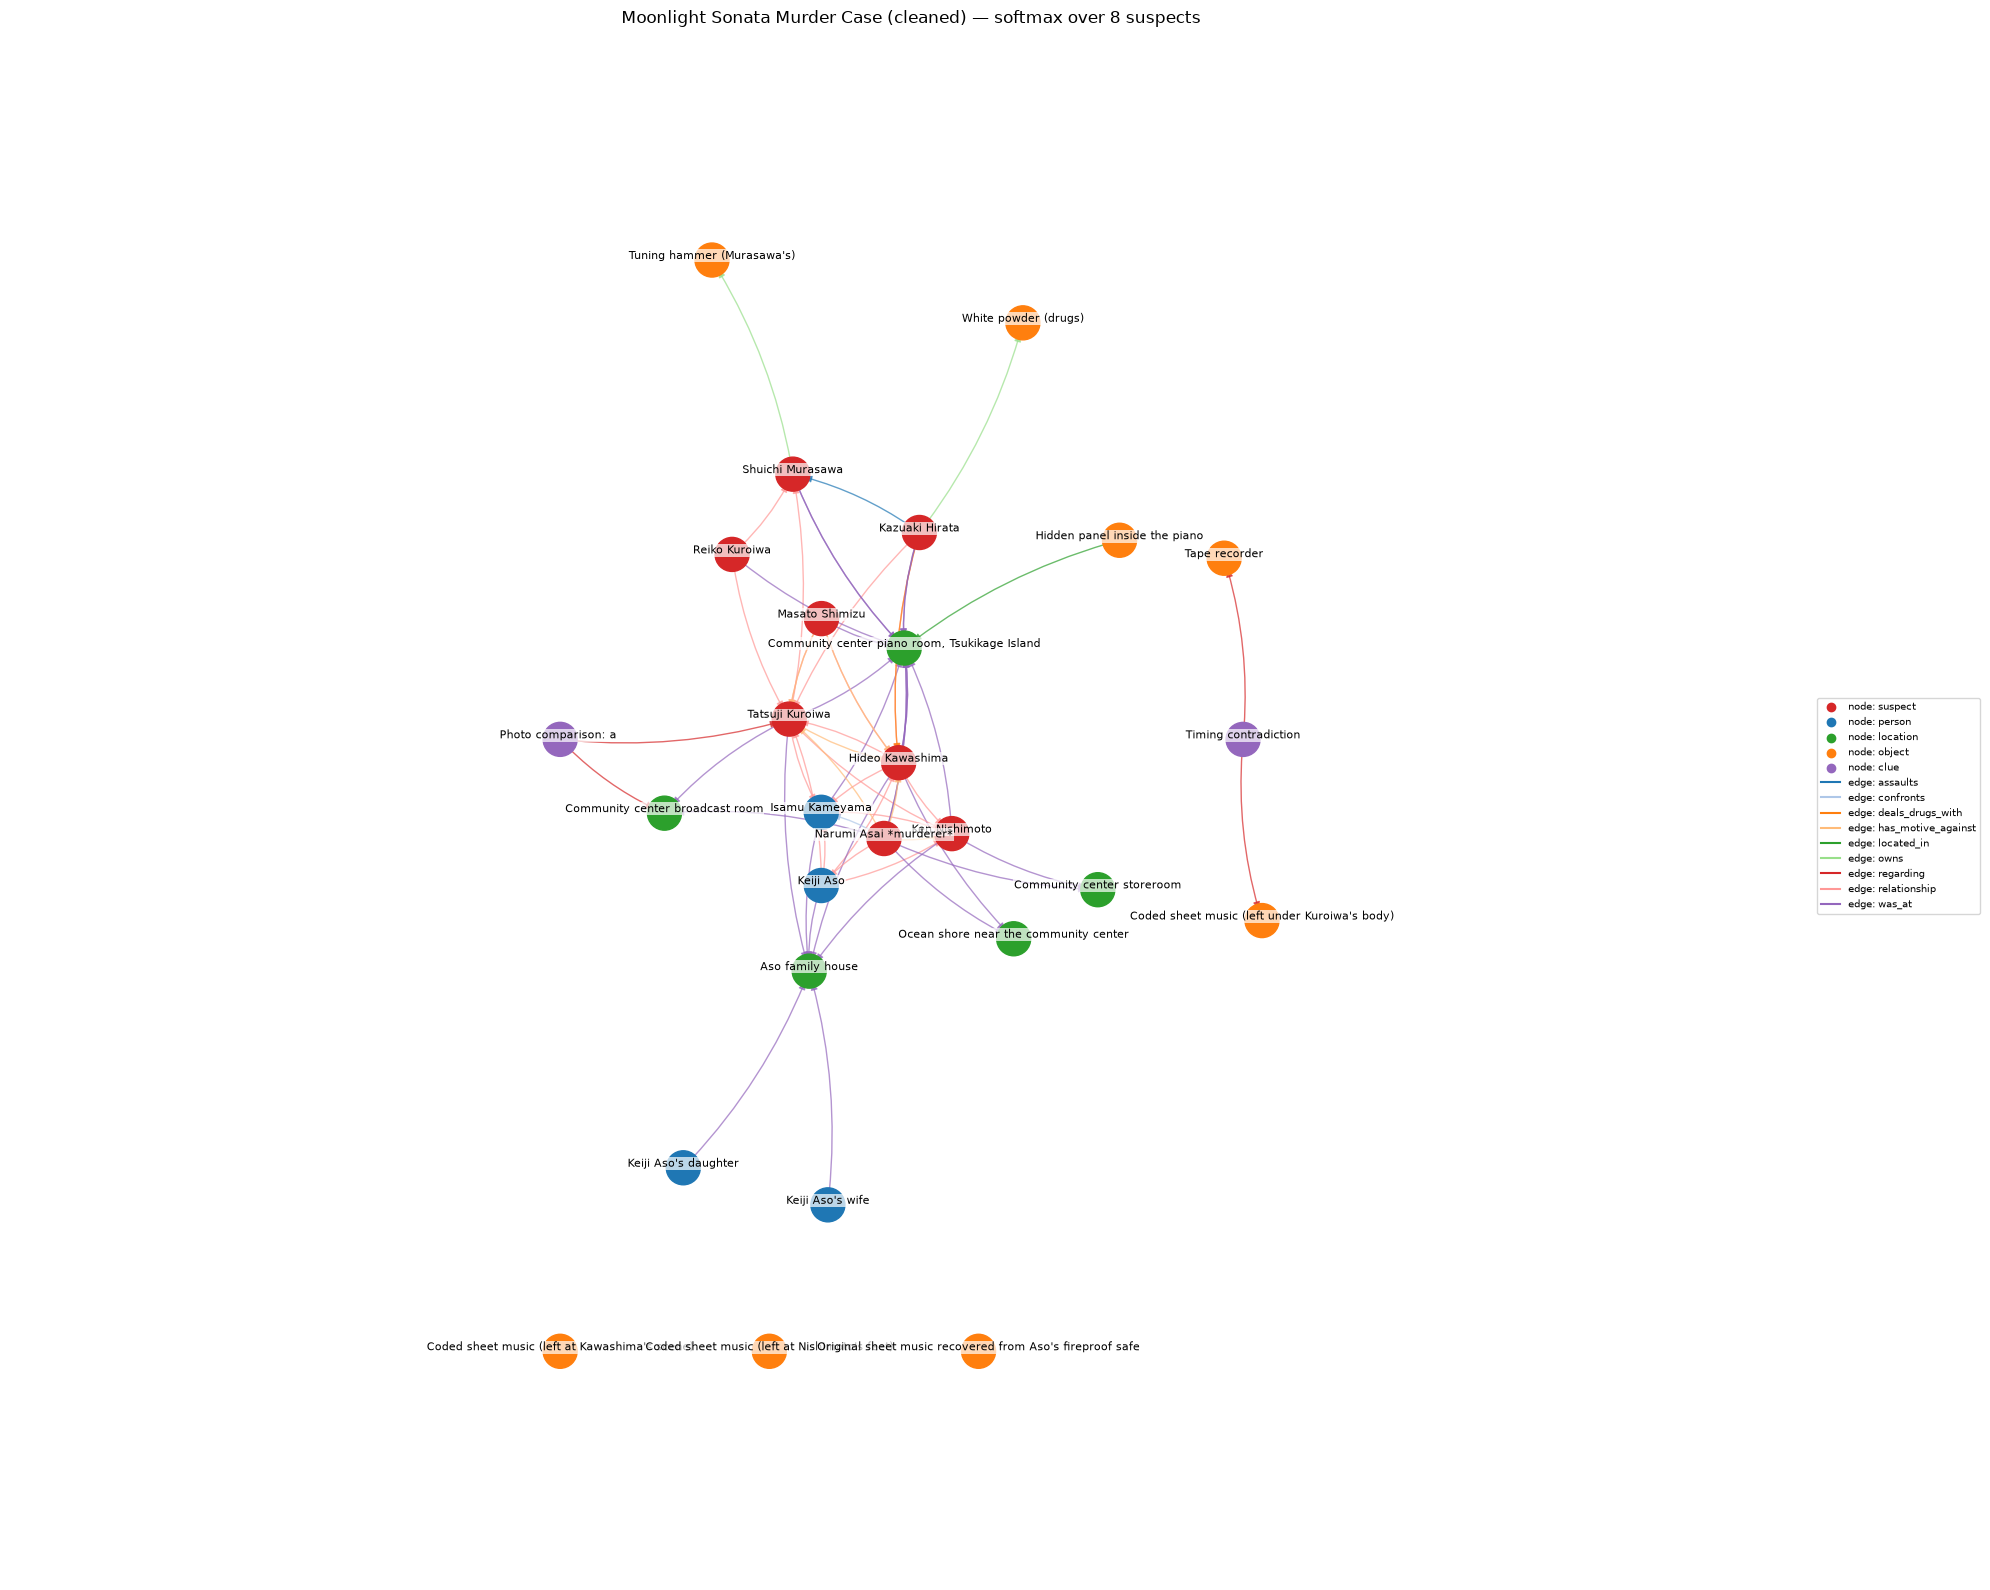

In [19]:
# --- visualize moonlight sonata (cleaned) -----------------------------------
example_clean = next(c for c in cleaned_cases if c["case_id"] == "ep011_moonlight_sonata_murder_case")

print(f"case: {example_clean['title']}")
print(f"edges before cleaning: {len(example['edges'])}   after: {len(example_clean['edges'])}")

draw_case(example_clean, title=f"{example_clean['title']} (cleaned) — softmax over {len(ex_suspects)} suspects")


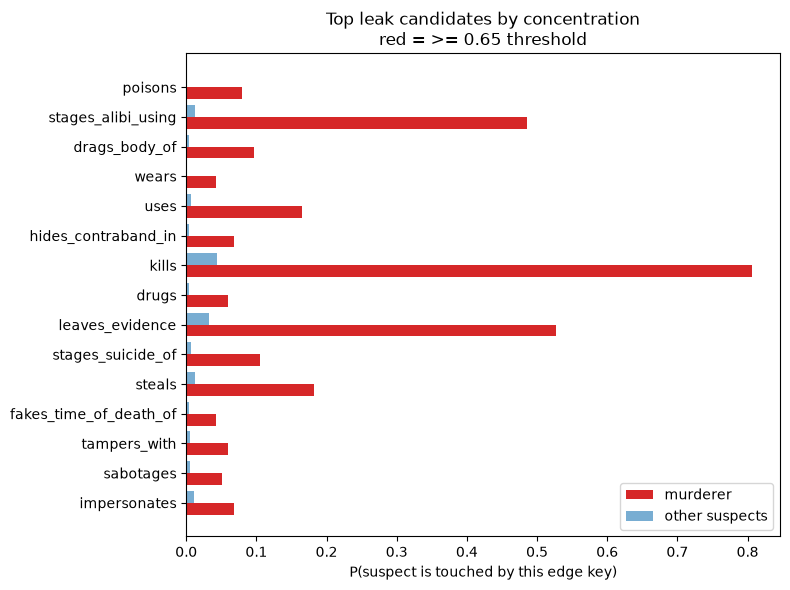

In [20]:
# --- viz: murderer-rate vs other-suspect-rate for the top leak candidates --
top = leak_df.head(15).iloc[::-1]
top_over = (top["category"] == "action") & (top["concentration"] >= EXCLUDE_THRESHOLD)
colors = ["tab:red" if over else "tab:gray" for over in top_over]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top))
ax.barh(y - 0.2, top["murderer_rate"], height=0.4, color=colors, label="murderer")
ax.barh(y + 0.2, top["other_suspect_rate"], height=0.4, color="tab:blue", alpha=0.6, label="other suspects")
ax.set_yticks(y); ax.set_yticklabels(top["edge_key"])
ax.set_xlabel("P(suspect is touched by this edge key)")
ax.set_title(f"Top leak candidates by concentration\nred = >= {EXCLUDE_THRESHOLD} threshold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


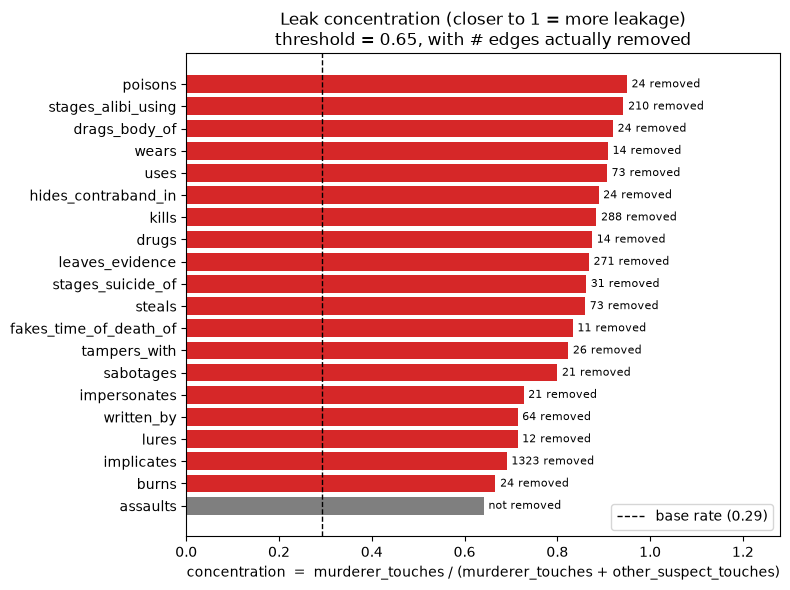

In [21]:
# --- viz: concentration score (0-1) + how many edges were actually removed -
top_conc = leak_df.head(20).iloc[::-1].copy()
top_conc["removed"] = top_conc["edge_key"].map(removed_edge_counts).fillna(0).astype(int)
top_over = (top_conc["category"] == "action") & (top_conc["concentration"] >= EXCLUDE_THRESHOLD)
colors = ["tab:red" if over else "tab:gray" for over in top_over]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top_conc))
bars = ax.barh(y, top_conc["concentration"], color=colors)
ax.axvline(base_rate, color="black", linestyle="--", linewidth=1, label=f"base rate ({base_rate:.2f})")

# label each bar with how many edges of that type were removed corpus-wide
for bar, removed, over in zip(bars, top_conc["removed"], top_over):
    label = f"{removed} removed" if over else "not removed"
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, label,
            va="center", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(top_conc["edge_key"])
ax.set_xlim(0, 1.28)
ax.set_xlabel("concentration  =  murderer_touches / (murderer_touches + other_suspect_touches)")
ax.set_title(f"Leak concentration (closer to 1 = more leakage)\nthreshold = {EXCLUDE_THRESHOLD}, with # edges actually removed")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [22]:
# --- persist the leak table (now including removed-edge counts) ------------
leak_df["edges_removed"] = leak_df["edge_key"].map(removed_edge_counts).fillna(0).astype(int)

out_path = "leak_candidates_v5.csv"
leak_df.to_csv(out_path, index=False)
print(f"saved {len(leak_df)} rows to {out_path}")


saved 29 rows to leak_candidates_v5.csv


### Findings

- Sanity check: `was_at` concentration 0.300 ≈ base rate 0.292.
- Strongest leaks: `poisons` (0.95), `stages_alibi_using` (0.94), `kills` (0.88), `implicates` (0.69, highest volume).
- 19 types auto-removed (support≥10, concentration≥0.65): 2,548/11,429 edges (22.3%).
- +21 removed manually below the support gate. Final: 40 types removed, 2,714/11,429 edges (23.7%).
- Kept: `owns, assaults, confronts, blackmails, threatens, frames` (0.48–0.64, under threshold); `has_motive_against` (0.43) and `relationship` (legitimate signal).

## 3. Train/val/test split, baseline, and GNN

Trains on `cleaned_cases` (leak-audited), not raw `cases_v3`.

### 3a. Split: grouped, stratified 5-fold CV

Split unit = case, stratified by suspect-count bucket (6+ pooled for the rare tail). Per fold: 80% train+val (85/15 split), 20% test.

In [23]:
# --- 5-fold grouped + stratified split, built once and reused by both models
from sklearn.model_selection import StratifiedKFold, train_test_split

N_FOLDS = 5
SPLIT_SEED = 42

def suspect_bucket(case):
    return min(n_suspects(case), 6)  # 6 stands for "6 or more" -- keeps every stratum >= 5 cases

clean_case_ids = np.array([c["case_id"] for c in cleaned_cases])
clean_buckets = np.array([suspect_bucket(c) for c in cleaned_cases])
print("suspect-bucket sizes:", dict(sorted(Counter(clean_buckets).items())))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SPLIT_SEED)

folds = []
for fold_i, (trainval_idx, test_idx) in enumerate(skf.split(clean_case_ids, clean_buckets)):
    trainval_ids, trainval_buckets = clean_case_ids[trainval_idx], clean_buckets[trainval_idx]
    train_ids, val_ids = train_test_split(
        trainval_ids, test_size=0.15, stratify=trainval_buckets, random_state=SPLIT_SEED
    )
    folds.append(dict(train=set(train_ids), val=set(val_ids), test=set(clean_case_ids[test_idx])))
    print(f"fold {fold_i}: train={len(train_ids):3d}  val={len(val_ids):3d}  test={len(test_idx):3d}")

# sanity: within each fold, train/val/test are disjoint and cover every case exactly once
for f in folds:
    assert not (f["train"] & f["val"]) and not (f["train"] & f["test"]) and not (f["val"] & f["test"])
    assert len(f["train"] | f["val"] | f["test"]) == len(cleaned_cases)
print("\nsplit sanity OK: disjoint within each fold, every case covered")


suspect-bucket sizes: {np.int64(2): 30, np.int64(3): 114, np.int64(4): 65, np.int64(5): 23, np.int64(6): 5}
fold 0: train=160  val= 29  test= 48
fold 1: train=160  val= 29  test= 48
fold 2: train=161  val= 29  test= 47
fold 3: train=161  val= 29  test= 47
fold 4: train=161  val= 29  test= 47

split sanity OK: disjoint within each fold, every case covered


### 3a½. Node `attrs` leak audit

Same concentration method applied to person `attrs` keys (used in the hashed text feature). Two-sided: P(murderer | key present) near 0 or 1 both signal a leak.

In [24]:
# --- node-attribute leak audit (mirrors the edge audit, applied to `attrs` keys) ---
NODE_LEAK_MIN_SUPPORT = 5
NODE_LEAK_LOW, NODE_LEAK_HIGH = 0.15, 0.60   # two-sided: near 0 = rules them out, near 1 = names them

attr_counts = defaultdict(lambda: [0, 0])   # key -> [murderer_count, other_count]
for c in cleaned_cases:
    murderer_id = c["label"]["murderer_id"]
    for p in c["nodes"]["persons"]:
        if "suspect" not in p.get("roles", []):
            continue
        is_m = p["id"] == murderer_id
        for k in p.get("attrs", {}).keys():
            attr_counts[k][0 if is_m else 1] += 1

node_leak_rows = []
for k, (m, o) in attr_counts.items():
    total = m + o
    if total < NODE_LEAK_MIN_SUPPORT:
        continue
    node_leak_rows.append(dict(attr_key=k, murderer_count=m, other_count=o, support=total, concentration=m / total))

node_leak_df = pd.DataFrame(node_leak_rows).sort_values("concentration", ascending=False).reset_index(drop=True)
LEAK_ATTRS = set(node_leak_df.loc[
    (node_leak_df["concentration"] >= NODE_LEAK_HIGH) | (node_leak_df["concentration"] <= NODE_LEAK_LOW),
    "attr_key"
])

print(f"{len(node_leak_df)} attrs keys with support >= {NODE_LEAK_MIN_SUPPORT}")
print(f"{len(LEAK_ATTRS)} flagged as leaks (concentration <= {NODE_LEAK_LOW} or >= {NODE_LEAK_HIGH}):")
print(sorted(LEAK_ATTRS))
node_leak_df


45 attrs keys with support >= 5
27 flagged as leaks (concentration <= 0.15 or >= 0.6):
['alibi', 'cleared', 'cleared_because', 'cleared_by', 'cleared_reason', 'confession', 'cover_story', 'detail', 'died_of', 'disguise', 'former_workplace', 'framed', 'framed_for', 'grudge', 'habit', 'method_summary', 'motive', 'motive_detail', 'motive_summary', 'note', 'relation_to_victim', 'role_in_case', 'scheme', 'skill', 'tell', 'trick', 'true_motive']


,attr_key,murderer_count,other_count,support,concentration
0,motive_summary,8,0,8,1.000000
1,true_motive,11,0,11,1.000000
2,trick,6,0,6,1.000000
3,method_summary,5,0,5,1.000000
4,tell,8,1,9,0.888889
5,motive_detail,16,2,18,0.888889
6,confession,30,5,35,0.857143
7,skill,6,1,7,0.857143
8,disguise,11,3,14,0.785714
9,cover_story,10,5,15,0.666667


In [25]:
# --- scrub leaky attrs before hashing node text (used by both models below) --
def person_text_safe(p):
    attrs = {k: v for k, v in p.get("attrs", {}).items() if k not in LEAK_ATTRS}
    return _flatten_text(p.get("name"), p.get("occupation"), p.get("aliases"), attrs)

print(f"scrubbing {len(LEAK_ATTRS)} leaky attrs keys out of every person's text feature "
      f"(applies to all persons, not just suspects, since witnesses/victims are still message-passing "
      f"neighbors in the GNN and could leak just as easily)")


scrubbing 27 leaky attrs keys out of every person's text feature (applies to all persons, not just suspects, since witnesses/victims are still message-passing neighbors in the GNN and could leak just as easily)


### 3b. Baseline: which non-graph model

Features (no `edge_index`): multi-hot roles, occupation-present flag, age + presence flag, 32-dim hashed bag-of-words over name/occupation/aliases/scrubbed `attrs`.

Model selection: LogisticRegression, RandomForest, HistGBT compared under an identical 5-fold protocol; highest mean top-1 wins.

Pooled binary classifier over suspect-rows, ranked within each test case for top-1/MRR.

In [26]:
# --- baseline: build one node-only feature row per suspect -----------------
from case_closed_dataset import _hash_bow, _flatten_text, TEXT_HASH_DIM

ROLE_VOCAB = sorted({r for c in cleaned_cases for p in c["nodes"]["persons"] for r in p.get("roles", [])})
role_index = {r: i for i, r in enumerate(ROLE_VOCAB)}
print(f"role vocab ({len(ROLE_VOCAB)}): {ROLE_VOCAB}")

suspect_rows, suspect_feats = [], []
for c in cleaned_cases:
    murderer_id = c["label"]["murderer_id"]
    for p in c["nodes"]["persons"]:
        if "suspect" not in p.get("roles", []):
            continue
        role_vec = np.zeros(len(ROLE_VOCAB))
        for r in p.get("roles", []):
            role_vec[role_index[r]] = 1.0                 # multi-hot: a suspect can hold >1 role at once
        text_vec = np.array(_hash_bow(person_text_safe(p)))  # leak-scrubbed text, see 3a1/2
        occ_present = 1.0 if p.get("occupation") else 0.0
        age = p.get("attrs", {}).get("age")
        age_val = float(age) if isinstance(age, (int, float)) else -1.0
        age_present = 1.0 if age_val >= 0 else 0.0
        suspect_feats.append(np.concatenate([role_vec, [occ_present, age_val, age_present], text_vec]))
        suspect_rows.append(dict(case_id=c["case_id"], suspect_id=p["id"],
                                  is_murderer=int(p["id"] == murderer_id)))

suspect_df = pd.DataFrame(suspect_rows)
X_baseline = np.stack(suspect_feats)
print(f"\nsuspect rows: {len(suspect_df)}   feature dim: {X_baseline.shape[1]} "
      f"({len(ROLE_VOCAB)} role + 1 occupation-flag + 1 age + 1 age-present + {TEXT_HASH_DIM} text-hash)")
print(f"positive rate (pooled): {suspect_df['is_murderer'].mean():.3f}")


role vocab (7): ['backstory_figure', 'bystander', 'client', 'investigator', 'suspect', 'victim', 'witness']

suspect rows: 811   feature dim: 42 (7 role + 1 occupation-flag + 1 age + 1 age-present + 32 text-hash)
positive rate (pooled): 0.292


In [27]:
# --- baseline: which model? compare, then commit to whichever actually won -
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

def evaluate_ranking(test_df):
    """test_df must have columns case_id, is_murderer, score. Returns (top1_acc, mrr)."""
    correct, total, rr_sum = 0, 0, 0.0
    for case_id, grp in test_df.groupby("case_id"):
        ranked = grp.sort_values("score", ascending=False).reset_index(drop=True)
        total += 1
        rank_of_murderer = int(ranked["is_murderer"].values.argmax()) + 1
        rr_sum += 1.0 / rank_of_murderer
        correct += int(rank_of_murderer == 1)
    return correct / total, rr_sum / total

def run_baseline_cv(make_clf, needs_scaling=False):
    accs, mrrs = [], []
    for fold in folds:
        train_mask = suspect_df["case_id"].isin(fold["train"]).values
        test_mask = suspect_df["case_id"].isin(fold["test"]).values
        Xtr, Xte = X_baseline[train_mask], X_baseline[test_mask]
        if needs_scaling:
            scaler = StandardScaler().fit(Xtr)
            Xtr, Xte = scaler.transform(Xtr), scaler.transform(Xte)
        clf = make_clf()
        clf.fit(Xtr, suspect_df.loc[train_mask, "is_murderer"])
        test_df = suspect_df.loc[test_mask].copy()
        test_df["score"] = clf.predict_proba(Xte)[:, 1]
        acc, mrr = evaluate_ranking(test_df)
        accs.append(acc); mrrs.append(mrr)
    return np.array(accs), np.array(mrrs)

candidates = {
    "LogisticRegression": (lambda: LogisticRegression(max_iter=2000, class_weight="balanced"), True),
    "RandomForest": (lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SPLIT_SEED), False),
    "HistGBT (default)": (lambda: HistGradientBoostingClassifier(max_iter=200, random_state=SPLIT_SEED), False),
    "HistGBT (tuned)": (lambda: HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, max_leaf_nodes=15,
                                                                 l2_regularization=1.0, random_state=SPLIT_SEED), False),
}

# run every candidate ONCE, keep the results -- the "winner" below is picked from
# these same numbers, not re-run separately, so the printed table and the final
# choice can never disagree with each other
baseline_results = {}
print(f"{'model':22s} {'top1_acc':>16s} {'mrr':>16s}")
for name, (make_clf, needs_scaling) in candidates.items():
    accs, mrrs = run_baseline_cv(make_clf, needs_scaling)
    baseline_results[name] = (accs, mrrs)
    print(f"{name:22s} {accs.mean():.3f} +/- {accs.std():.3f}   {mrrs.mean():.3f} +/- {mrrs.std():.3f}")

# --- winner: whichever has the highest mean top-1 accuracy, decided from the
# table above, not assumed in advance ---
best_name = max(baseline_results, key=lambda k: baseline_results[k][0].mean())
baseline_accs, baseline_mrrs = baseline_results[best_name]
print(f"\nWinner (highest mean top-1 accuracy): {best_name}")
print(f"Final baseline ({best_name}): top1_acc = {baseline_accs.mean():.3f} +/- {baseline_accs.std():.3f}")
print(f"Final baseline ({best_name}): mrr      = {baseline_mrrs.mean():.3f} +/- {baseline_mrrs.std():.3f}")


model                          top1_acc              mrr


LogisticRegression     0.603 +/- 0.061   0.768 +/- 0.031


RandomForest           0.535 +/- 0.119   0.738 +/- 0.060


HistGBT (default)      0.455 +/- 0.112   0.695 +/- 0.056


HistGBT (tuned)        0.468 +/- 0.081   0.704 +/- 0.040

Winner (highest mean top-1 accuracy): LogisticRegression
Final baseline (LogisticRegression): top1_acc = 0.603 +/- 0.061
Final baseline (LogisticRegression): mrr      = 0.768 +/- 0.031


### 3c. Edge-type bucket taxonomy

582 raw action types, mostly single-digit support → collapsed into semantic buckets: `presence`, `possession`, `social`, `conflict_harm`, `concealment` (excluded, see 3d), `discovery`, `other_misc` (catch-all). Kept individual: `has_motive_against`, `regarding`, `relationship`.

In [28]:
# --- bucket taxonomy: collapse 582 action keys into a handful of categories --
import re

KEEP_INDIVIDUAL = {"has_motive_against", "regarding", "relationship"}

BUCKET_RULES = [
  ("conflict_harm", [r"assault", r"injur", r"wound", r"attempts_to_kill", r"attempts_murder", r"kidnap", r"abduct",
      r"restrain", r"ties_up", r"chain", r"bind", r"trap", r"drags_into_river", r"weighs_down_body", r"knocks_",
      r"stun", r"renders_unconscious", r"subdue", r"chloroform", r"sedat", r"gasses", r"contaminat",
      r"applies_poison", r"laces_with", r"tranquiliz", r"infect", r"taints", r"suicide", r"causes_death",
      r"causes_accident", r"causes_fall", r"causes_blackout", r"indirectly_causes_death", r"responsible_for_death",
      r"drives_to_drink", r"suffocate", r"cuts_throat", r"^attacks$", r"endanger", r"harass", r"threaten",
      r"provok", r"pressures", r"coerc", r"forces_draw", r"takes_hostage", r"holds_captive", r"^arms$", r"^fires$",
      r"throws_knife", r"sets_up", r"punctur", r"drills_hole", r"cracks_hole", r"corrode", r"blackmail",
      r"extort", r"bribe", r"^scams$", r"defraud", r"embezzl", r"misappropriat", r"mismanages_investment",
      r"^exploits", r"sabotage", r"ruins_business", r"causes_firing", r"blocks_career", r"threatens_closure",
      r"demands_", r"refuses_loan", r"destroy", r"damag", r"^breaks$", r"break_into$", r"smash", r"shatter",
      r"vandaliz", r"crash", r"collide", r"^rams$", r"burns", r"sets_fire", r"ignites_fire", r"extinguish",
      r"floods", r"tears", r"^cuts$", r"disturbs", r"strikes", r"triggers", r"plans_to_kill",
      r"rigs_chemical_trick_at", r"creates_locked_room_using", r"manipulates", r"^pushes$", r"^grabs$",
      r"orders_killing_of", r"leaves_to_die", r"fires_blank_at", r"plants_explosives_in", r"detonates",
      r"remote_drives", r"operates_remotely"]),
  ("concealment", [r"^hides$", r"hides_", r"conceal", r"^disposes", r"dumps", r"buries", r"discard",
      r"removes_evidence", r"removes_from_scene", r"wipes_", r"plants_evidence", r"disguise", r"^poses_as$",
      r"impersonat", r"infiltrat", r"^swaps", r"^switch", r"reposition", r"positions_body", r"drags_body",
      r"moves_body", r"lowers_body", r"loads_body", r"relocates_body", r"recovers_body", r"traps_body",
      r"^stages_", r"^restages_", r"^fakes_", r"^false", r"^falsely", r"gives_false", r"confirms_alibi",
      r"undermines_alibi", r"crafts_alibi", r"requests_false_alibi", r"makes_false_statement",
      r"reports_false", r"sends_fake", r"simulates_presence", r"obstructs_", r"^blocks_(?!career)",
      r"^locks", r"unlocks", r"leaves_unlocked", r"disguises_lock", r"covertly_opens", r"embeds_message",
      r"encodes_message", r"disguises_sound", r"rigs_evidence", r"fabricat", r"controls_access",
      r"publishes_false", r"sold_forgery", r"^forges$", r"frames", r"deceives", r"poses_body_of",
      r"^positions$", r"drops_body_of", r"abandons_body_at", r"misdirects", r"erases", r"deletes_evidence"]),
  ("discovery", [r"discover", r"^finds$", r"^found$", r"witness", r"^observes$", r"spies", r"tracks", r"stalks",
      r"investigat", r"examines", r"inspects", r"searches", r"decodes", r"identifies", r"confirms_identity",
      r"locates", r"learns_of", r"^views$", r"photographs", r"^records$", r"excavat", r"detains",
      r"apprehends", r"questions", r"interviews", r"interrogat", r"recovers_weapon", r"plants_bug_in",
      r"^suspects$"]),
  ("social", [r"^calls", r"^sends", r"leaves_message", r"leaves_dying_message", r"corresponds",
      r"writes_message", r"^signals", r"broadcasts", r"^arranges", r"meets_with", r"^alerts$", r"^warns$",
      r"advises", r"instructs", r"^orders$", r"^requests", r"proposes", r"declines_proposal", r"confess",
      r"confides", r"^accuses$", r"testifies", r"withholds_", r"leaks_information", r"^notifies$",
      r"reports_on", r"reports_body_location", r"interrupts_call", r"gloats", r"pleads", r"^chooses$",
      r"^selects$", r"^confronts$", r"insult", r"^mocks$", r"taunts", r"berates", r"humiliat", r"badmouth",
      r"slander", r"smear", r"torments", r"pesters", r"frightens", r"startles", r"argues", r"challenges",
      r"^rejects$", r"^forbids$", r"^dismisses$", r"betrays", r"distances_from", r"breaks_up_with",
      r"writes_negative_review_of", r"^protects$", r"protects_from", r"^rescues$", r"^saves$", r"^teaches$",
      r"^trains$", r"^treats$", r"motivat", r"^encourages$", r"consoles", r"shields", r"^assists",
      r"shelters", r"entrusts_care", r"hires_for_protection", r"^recruits", r"recommends", r"^manages$",
      r"^represents", r"advocates", r"delays_search", r"funds_treatment", r"dissuades", r"prevents_suicide",
      r"attempts_to_rescue", r"foils_theft_against", r"deals_drugs_with", r"gambles_with"]),
  ("possession", [r"^owns$", r"^has_access", r"^takes$", r"^robs$", r"^retrieves$", r"^gives$", r"given_",
      r"^delivers$", r"delivered_to", r"^buys$", r"^purchases$", r"^sells", r"sold_", r"^borrows$",
      r"^holds$", r"held_by", r"^handles$", r"picks_up", r"^drops$", r"^seizes$", r"^collects",
      r"^carries$", r"^brings$", r"entrusts_to", r"entrusted_to", r"^receives", r"^wears$", r"worn_by",
      r"^uses$", r"uses_passage", r"uses_as_lure", r"crafted_by", r"^made$", r"^authors$", r"ghostwrites",
      r"^writes$", r"painted_by", r"^paints$", r"^builds$", r"^constructs$", r"manufactur",
      r"^reassembles$", r"^repairs$", r"^modifies$", r"^replaces$", r"^resizes$", r"^appraises$",
      r"plagiariz", r"credited_to", r"falsely_attributed", r"recites_as_own", r"sews", r"^bakes$",
      r"^digs$", r"fashions_weapon", r"^assembles$", r"^creates$", r"stolen_from", r"attempts_to_steal",
      r"attempts_theft", r"attempts_to_buy", r"negotiates_sale", r"signs_contract", r"loads_into",
      r"^consumes$", r"unknowingly_carries", r"mistakenly_takes_home", r"reuses_parts_of", r"transports"]),
  ("presence", [r"^was_at$", r"^located_in$", r"employed_at", r"studied_at", r"resides_at", r"^works_at$",
      r"^worked_at$", r"^frequents$", r"crashes_at", r"^visits$", r"returns_to", r"lands_on", r"flies_to",
      r"descends_to", r"memorial_held", r"rehearses_at", r"sent_to", r"escapes_through", r"sneaks_into",
      r"^burgles$", r"^flees", r"flees_", r"^strands$", r"^encounters$", r"^chases$", r"^meets$",
      r"breaks_into"]),
]

def _edge_bucket_key(key):
    """Collapse a raw _edge_relation_key() value into one of the 9 categories
    above. High-value/high-frequency keys that are a different *kind* of
    fact rather than a rare action variant are kept individual instead."""
    if key in KEEP_INDIVIDUAL:
        return key
    for bucket, patterns in BUCKET_RULES:
        for pat in patterns:
            if re.search(pat, key):
                return bucket
    return "other_misc"

bucket_edge_counter = Counter()
for c in cleaned_cases:
    for e in c["edges"]:
        bucket_edge_counter[_edge_bucket_key(_edge_relation_key(e))] += 1
total_bucket_edges = sum(bucket_edge_counter.values())

print(f"9 action-side categories + relationship = {len(bucket_edge_counter)} edge-type categories total "
      f"(was 583 raw keys), {total_bucket_edges} edges\n")
for k, v in bucket_edge_counter.most_common():
    print(f"  {k:20s} {v:5d}  ({100*v/total_bucket_edges:5.1f}%)")


9 action-side categories + relationship = 10 edge-type categories total (was 583 raw keys), 8715 edges

  presence              3497  ( 40.1%)
  relationship          1343  ( 15.4%)
  regarding             1294  ( 14.8%)
  possession             823  (  9.4%)
  has_motive_against     599  (  6.9%)
  conflict_harm          366  (  4.2%)
  social                 314  (  3.6%)
  concealment            246  (  2.8%)
  other_misc             137  (  1.6%)
  discovery               96  (  1.1%)

### 3d. Bucket-level leak audit

Same concentration method as Section 2, applied to buckets instead of raw keys — individually-rare leaky verbs can pool into a bucket that clears the support gate.

In [29]:
# --- concentration audit, but on buckets instead of raw keys ----------------
def concentration_by_key(key_fn):
    murderer_touch, other_touch, case_support = Counter(), Counter(), defaultdict(set)
    for c in cleaned_cases:
        persons = c["nodes"]["persons"]
        suspect_ids = {p["id"] for p in persons if "suspect" in p.get("roles", [])}
        murderer_id = c["label"]["murderer_id"]
        other_ids = suspect_ids - {murderer_id}
        touched_by = defaultdict(set)
        for e in c["edges"]:
            key = key_fn(_edge_relation_key(e))
            for endpoint in (e["from"], e["to"]):
                if endpoint in suspect_ids:
                    touched_by[key].add(endpoint)
        for key, ids in touched_by.items():
            case_support[key].add(c["case_id"])
            if murderer_id in ids:
                murderer_touch[key] += 1
            other_touch[key] += len(ids & other_ids)
    rows = []
    for key, cids in case_support.items():
        m, o = murderer_touch[key], other_touch[key]
        rows.append(dict(key=key, support_cases=len(cids), murderer_touches=m,
                          other_suspect_touches=o, concentration=(m / (m + o)) if (m + o) > 0 else float("nan")))
    return pd.DataFrame(rows).sort_values("concentration", ascending=False).reset_index(drop=True)

bucket_concentration = concentration_by_key(_edge_bucket_key)
print(f"base rate: {base_rate:.3f}   EXCLUDE_THRESHOLD (Section 2): {EXCLUDE_THRESHOLD}\n")
print(bucket_concentration.to_string(index=False))


base rate: 0.292   EXCLUDE_THRESHOLD (Section 2): 0.65

               key  support_cases  murderer_touches  other_suspect_touches  concentration
       concealment            122               113                     63       0.642045
     conflict_harm            146               126                     91       0.580645
        other_misc             59                46                     38       0.547619
        possession            203               176                    151       0.538226
            social            134               105                    123       0.460526
         discovery             49                26                     34       0.433333
has_motive_against            232               232                    304       0.432836
         regarding            126                75                    138       0.352113
      relationship            226               216                    441       0.328767
          presence            237           

`concealment`: 0.642 concentration, essentially at the 0.65 line — same category as Section 2's excluded post-hoc-narration verbs. Excluded.

`conflict_harm`: 0.58 — kept, same rationale as `has_motive_against`/`relationship` (legitimate suspicious-behavior signal).

Ablation: dropping `concealment` costs nothing (0.877 vs 0.893 top-1, p=0.31) — excluded on principle, not because the model needs it gone.

In [30]:
# --- exclude the concealment bucket from the final edge vocabulary ----------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data

GNN_NODE_TYPES = ["person", "location", "object", "clue"]
GNN_ROLE_VOCAB = sorted(
    {r for c in cleaned_cases for p in c["nodes"]["persons"] for r in p.get("roles", [])}
    | {o.get("role") for c in cleaned_cases for o in c["nodes"]["objects"] if o.get("role")}
    | {cl.get("clue_type") for c in cleaned_cases for cl in c["nodes"]["clues"] if cl.get("clue_type")}
)
gnn_role_index = {r: i for i, r in enumerate(GNN_ROLE_VOCAB)}
GNN_FEATURE_DIM = len(GNN_NODE_TYPES) + len(GNN_ROLE_VOCAB) + TEXT_HASH_DIM

DROPPED_BUCKETS = {"concealment"}

EDGE_KEY_VOCAB_FINAL = sorted({_edge_bucket_key(_edge_relation_key(e)) for c in cleaned_cases for e in c["edges"]}
                               - DROPPED_BUCKETS)
edge_key_index_final = {k: i for i, k in enumerate(EDGE_KEY_VOCAB_FINAL)}
NUM_RELATIONS = len(EDGE_KEY_VOCAB_FINAL)
print(f"GNN node-type count: {len(GNN_NODE_TYPES)}   role vocab: {len(GNN_ROLE_VOCAB)}   feature dim: {GNN_FEATURE_DIM}")
print(f"final edge vocab ({NUM_RELATIONS} categories, concealment excluded): {EDGE_KEY_VOCAB_FINAL}")


def encode_case_for_gnn(case):
    node_ids, node_type, node_feat, suspect_mask = [], [], [], []

    def add_node(nid, ntype, role_key, text, is_suspect=False):
        t_idx = GNN_NODE_TYPES.index(ntype)
        type_oh = np.zeros(len(GNN_NODE_TYPES)); type_oh[t_idx] = 1.0
        role_oh = np.zeros(len(GNN_ROLE_VOCAB))
        if role_key in gnn_role_index:
            role_oh[gnn_role_index[role_key]] = 1.0
        text_vec = np.array(_hash_bow(text))
        node_ids.append(nid)
        node_type.append(t_idx)
        node_feat.append(np.concatenate([type_oh, role_oh, text_vec]))
        suspect_mask.append(is_suspect)

    murderer_id = case["label"]["murderer_id"]
    suspect_ids = []
    for p in case["nodes"]["persons"]:
        roles = p.get("roles", [])
        is_susp = "suspect" in roles
        add_node(p["id"], "person", roles[0] if roles else None, person_text_safe(p), is_suspect=is_susp)
        if is_susp:
            suspect_ids.append(p["id"])
    for loc in case["nodes"]["locations"]:
        add_node(loc["id"], "location", None, _flatten_text(loc.get("name"), loc.get("attrs")))
    for obj in case["nodes"]["objects"]:
        add_node(obj["id"], "object", obj.get("role"), _flatten_text(obj.get("name"), obj.get("attrs")))
    for clue in case["nodes"]["clues"]:
        add_node(clue["id"], "clue", clue.get("clue_type"), _flatten_text(clue.get("desc")))

    id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    src, dst, etype = [], [], []
    for e in case["edges"]:
        a, b = e["from"], e["to"]
        if a not in id_to_idx or b not in id_to_idx:
            continue
        bucket = _edge_bucket_key(_edge_relation_key(e))
        if bucket in DROPPED_BUCKETS:
            continue
        k = edge_key_index_final[bucket]
        src += [id_to_idx[a], id_to_idx[b]]
        dst += [id_to_idx[b], id_to_idx[a]]
        etype += [k, k]

    d = Data(x=torch.tensor(np.stack(node_feat), dtype=torch.float),
              edge_index=torch.tensor([src, dst], dtype=torch.long),
              edge_type=torch.tensor(etype, dtype=torch.long))
    d.node_type = torch.tensor(node_type, dtype=torch.long)
    d.suspect_mask = torch.tensor(suspect_mask, dtype=torch.bool)
    d.murderer_local_idx = torch.tensor([suspect_ids.index(murderer_id)], dtype=torch.long)
    d.person_ids = [p["id"] for p in case["nodes"]["persons"]]
    d.suspect_ids = suspect_ids
    d.case_id = case["case_id"]
    return d

gnn_data_by_case = {c["case_id"]: encode_case_for_gnn(c) for c in cleaned_cases}
print(f"encoded {len(gnn_data_by_case)} graphs")


GNN node-type count: 4   role vocab: 17   feature dim: 53
final edge vocab (9 categories, concealment excluded): ['conflict_harm', 'discovery', 'has_motive_against', 'other_misc', 'possession', 'presence', 'regarding', 'relationship', 'social']
encoded 237 graphs

### 3e. GNN model: GINEConv

Nodes: `person`, `location`, `object`, `clue`. Edges: bucketed types (3c/3d), bidirectional. Features (53-dim): node-type one-hot(4) + role one-hot(17) + 32-dim hashed bag-of-words text.

Model: `GINEConv`, 2 layers, hidden=32. Edge bucket embedded (16-dim) and added into the message — no attention. Compared against HEATConv/RGATConv/RGCNConv/TransformerConv (3 seeds × 5 folds); GINEConv won (p<0.002 vs. attention-based, p=0.07 vs. RGCN). **Section 4 shows this "win" is largely GINEConv's sum aggregation exploiting a degree-correlated shortcut, not superior reasoning** — kept as the model regardless since it's still the strongest option tried.

Loss: per-graph masked softmax + cross-entropy. Metrics: top-1 accuracy (primary), MRR (secondary); confusion matrix/ROC in Section 4. Split: same 5-fold as the baseline, best-val-loss checkpointing.

In [31]:
# --- GNN: GINEConv model + per-graph masked-softmax loss/eval ---------------
from torch_geometric.nn import GINEConv

class CaseClosedGNN(nn.Module):
    def __init__(self, in_dim, num_relations=NUM_RELATIONS, hidden=32, edge_emb_dim=16):
        super().__init__()
        self.edge_emb = nn.Embedding(num_relations, edge_emb_dim)
        mlp1 = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        mlp2 = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.c1 = GINEConv(mlp1, edge_dim=edge_emb_dim)
        self.c2 = GINEConv(mlp2, edge_dim=edge_emb_dim)
        self.drop = nn.Dropout(0.2)
        self.score = nn.Linear(hidden, 1)

    def forward(self, data):
        ea = self.edge_emb(data.edge_type)
        x = F.relu(self.c1(data.x, data.edge_index, ea))
        x = self.drop(x)
        x = F.relu(self.c2(x, data.edge_index, ea))
        return self.score(x).squeeze(-1)


def per_graph_loss_acc_rr(scores, batch):
    """Masked softmax over each graph's suspect nodes only, per-graph
    cross-entropy against murderer_local_idx -- the per-graph softmax +
    cross-entropy from Section 1, applied to a batch of case-graphs."""
    total_loss, correct, rr_sum = 0.0, 0, 0.0
    for g in range(batch.num_graphs):
        mask = (batch.batch == g) & batch.suspect_mask
        g_scores = scores[mask]
        target = batch.murderer_local_idx[g]
        total_loss = total_loss - F.log_softmax(g_scores, dim=0)[target]
        rank = int((g_scores > g_scores[target]).sum().item()) + 1
        rr_sum += 1.0 / rank
        correct += int(rank == 1)
    return total_loss / batch.num_graphs, correct, rr_sum


@torch.no_grad()
def evaluate_gnn(model, loader):
    """Returns (top1_acc, mrr, mean_loss) -- loss is used for checkpoint
    selection, accuracy/MRR for reporting."""
    model.eval()
    correct, total, rr_sum, loss_sum = 0, 0, 0.0, 0.0
    for batch in loader:
        loss, c, rr = per_graph_loss_acc_rr(model(batch), batch)
        loss_sum += loss.item() * batch.num_graphs
        correct += c; rr_sum += rr; total += batch.num_graphs
    return correct / total, rr_sum / total, loss_sum / total


### 3f. Training: 5-fold CV

40 epochs/fold, best-val-loss checkpoint, saved to `models_v5/` bundled with the exact vocab used.

In [32]:
# --- GNN: 5-fold CV training with best-val-loss checkpointing ---------------
import copy, os
from torch_geometric.loader import DataLoader

N_EPOCHS = 40
DEFAULT_SEED = 42
MODEL_OUT_DIR = os.path.join(os.getcwd(), "models_v5")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

t0 = time.time()
gnn_accs, gnn_mrrs = [], []
for fold_i, fold in enumerate(folds):
    train_loader = DataLoader([gnn_data_by_case[i] for i in fold["train"]], batch_size=16, shuffle=True)
    val_loader = DataLoader([gnn_data_by_case[i] for i in fold["val"]], batch_size=32)
    test_loader = DataLoader([gnn_data_by_case[i] for i in fold["test"]], batch_size=32)

    torch.manual_seed(DEFAULT_SEED)
    model = CaseClosedGNN(GNN_FEATURE_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val_loss, best_state = 1e9, None
    for epoch in range(N_EPOCHS):
        model.train()
        for batch in train_loader:
            opt.zero_grad()
            loss, _, _ = per_graph_loss_acc_rr(model(batch), batch)
            loss.backward(); opt.step()
        _, _, val_loss = evaluate_gnn(model, val_loader)
        if val_loss < best_val_loss:
            best_val_loss, best_state = val_loss, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    test_acc, test_mrr, _ = evaluate_gnn(model, test_loader)
    gnn_accs.append(test_acc); gnn_mrrs.append(test_mrr)

    ckpt_path = os.path.join(MODEL_OUT_DIR, f"gineconv_fold{fold_i}.pt")
    torch.save({
        "state_dict": best_state, "in_dim": GNN_FEATURE_DIM, "num_relations": NUM_RELATIONS,
        "edge_vocab": EDGE_KEY_VOCAB_FINAL, "gnn_role_vocab": GNN_ROLE_VOCAB, "gnn_node_types": GNN_NODE_TYPES,
        "fold": fold_i, "test_acc": test_acc, "test_mrr": test_mrr,
    }, ckpt_path)
    print(f"fold {fold_i}: best_val_loss={best_val_loss:.3f}  test_acc={test_acc:.3f}  test_mrr={test_mrr:.3f}  -> saved {os.path.basename(ckpt_path)}")

print(f"\nCaseClosedGNN (GINEConv, bucketed + leak-audited edges): "
      f"top1_acc = {np.mean(gnn_accs):.3f} +/- {np.std(gnn_accs):.3f}")
print(f"mrr = {np.mean(gnn_mrrs):.3f} +/- {np.std(gnn_mrrs):.3f}")
print(f"({N_FOLDS} folds x {N_EPOCHS} epochs took {time.time()-t0:.0f}s)")


fold 0: best_val_loss=0.284  test_acc=0.812  test_mrr=0.899  -> saved gineconv_fold0.pt
fold 1: best_val_loss=0.206  test_acc=0.854  test_mrr=0.918  -> saved gineconv_fold1.pt
fold 2: best_val_loss=0.179  test_acc=0.872  test_mrr=0.933  -> saved gineconv_fold2.pt
fold 3: best_val_loss=0.285  test_acc=0.936  test_mrr=0.968  -> saved gineconv_fold3.pt
fold 4: best_val_loss=0.320  test_acc=0.872  test_mrr=0.924  -> saved gineconv_fold4.pt

CaseClosedGNN (GINEConv, bucketed + leak-audited edges): top1_acc = 0.870 +/- 0.040
mrr = 0.928 +/- 0.023
(5 folds x 40 epochs took 16s)

Single seed (42), for a reproducible checkpoint. Trustworthy estimate: 3-seed × 5-fold = 0.877±0.048 top-1 / 0.934±0.026 MRR (3d ablation, "no_concealment").

### 3g. Baseline vs GNN

LogisticRegression baseline:  top1=0.603+/-0.061   mrr=0.768+/-0.031
GINEConv GNN:           top1=0.870+/-0.040   mrr=0.928+/-0.023

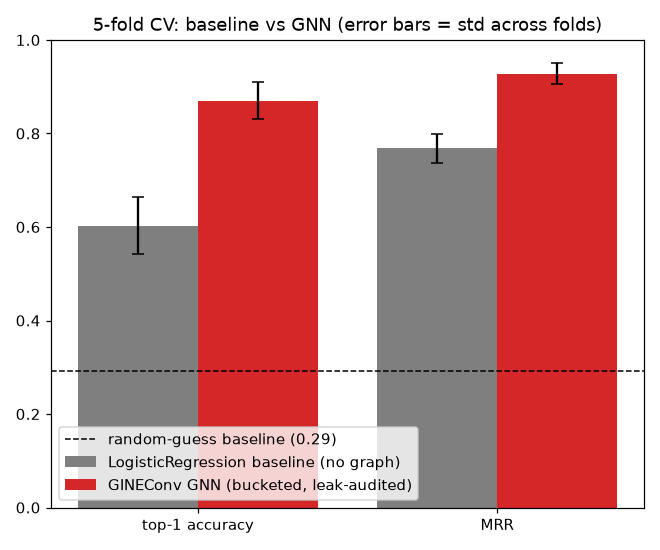

In [33]:
# --- viz: baseline vs GINEConv GNN, mean +/- std across folds ---------------
metrics = ["top-1 accuracy", "MRR"]
baseline_means_ = [baseline_accs.mean(), baseline_mrrs.mean()]
baseline_stds_ = [baseline_accs.std(), baseline_mrrs.std()]
gnn_means = [np.mean(gnn_accs), np.mean(gnn_mrrs)]
gnn_stds = [np.std(gnn_accs), np.std(gnn_mrrs)]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - 0.2, baseline_means_, width=0.4, yerr=baseline_stds_, capsize=4, color="tab:gray",
       label=f"{best_name} baseline (no graph)")
ax.bar(x + 0.2, gnn_means, width=0.4, yerr=gnn_stds, capsize=4, color="tab:red",
       label="GINEConv GNN (bucketed, leak-audited)")
ax.axhline(base_rate, color="black", linestyle="--", linewidth=1, label=f"random-guess baseline ({base_rate:.2f})")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("5-fold CV: baseline vs GNN (error bars = std across folds)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{best_name} baseline:  top1={baseline_means_[0]:.3f}+/-{baseline_stds_[0]:.3f}   mrr={baseline_means_[1]:.3f}+/-{baseline_stds_[1]:.3f}")
print(f"GINEConv GNN:           top1={gnn_means[0]:.3f}+/-{gnn_stds[0]:.3f}   mrr={gnn_means[1]:.3f}+/-{gnn_stds[1]:.3f}")


## 4. Evaluation & Error Analysis

Confusion matrix + ROC/AUC on the pooled binary decision ("is this suspect the murderer"), v1 (baseline) vs. v2 (GNN), pooled across all 5 test folds.

Confusion matrix uses per-case argmax (exactly one predicted murderer per case → precision = recall = top-1 accuracy by construction). ROC/AUC uses the continuous score directly.

In [34]:
# --- pooled out-of-fold predictions: v1 baseline vs v2 GNN, every test fold -
from sklearn.metrics import confusion_matrix, roc_curve, auc

def add_top_pick(df):
    """argmax-per-case binarization: exactly one top pick per case."""
    df = df.reset_index(drop=True)
    df["n_suspects"] = df.groupby("case_id")["suspect_id"].transform("count")
    df["is_top_pick"] = 0
    top_idx = df.groupby("case_id")["score"].idxmax()
    df.loc[top_idx, "is_top_pick"] = 1
    return df

# v1: rerun the baseline once more, but this time keep every suspect-row's
# score (not just the scalar accuracy) pooled across all 5 test folds
v1_rows = []
for fold in folds:
    train_mask = suspect_df["case_id"].isin(fold["train"]).values
    test_mask = suspect_df["case_id"].isin(fold["test"]).values
    Xtr, Xte = X_baseline[train_mask], X_baseline[test_mask]
    scaler = StandardScaler().fit(Xtr)
    Xtr, Xte = scaler.transform(Xtr), scaler.transform(Xte)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(Xtr, suspect_df.loc[train_mask, "is_murderer"])
    test_df = suspect_df.loc[test_mask, ["case_id", "suspect_id", "is_murderer"]].copy()
    test_df["score"] = clf.predict_proba(Xte)[:, 1]
    v1_rows.append(test_df)
v1_pred = add_top_pick(pd.concat(v1_rows, ignore_index=True))

# v2: same idea for the GNN -- rerun 5-fold CV, keep every suspect's softmax score
v2_rows = []
for fold_i, fold in enumerate(folds):
    train_loader = DataLoader([gnn_data_by_case[i] for i in fold["train"]], batch_size=16, shuffle=True)
    val_loader = DataLoader([gnn_data_by_case[i] for i in fold["val"]], batch_size=32)
    test_cases = [gnn_data_by_case[i] for i in fold["test"]]

    torch.manual_seed(DEFAULT_SEED)
    model = CaseClosedGNN(GNN_FEATURE_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_val_loss, best_state = 1e9, None
    for epoch in range(N_EPOCHS):
        model.train()
        for batch in train_loader:
            opt.zero_grad()
            loss, _, _ = per_graph_loss_acc_rr(model(batch), batch)
            loss.backward(); opt.step()
        _, _, val_loss = evaluate_gnn(model, val_loader)
        if val_loss < best_val_loss:
            best_val_loss, best_state = val_loss, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        for data in test_cases:
            scores = model(data)
            susp_scores = scores[data.suspect_mask]
            probs = F.softmax(susp_scores, dim=0).numpy()
            murderer_local = data.murderer_local_idx.item()
            for i, sid in enumerate(data.suspect_ids):
                v2_rows.append(dict(case_id=data.case_id, suspect_id=sid,
                                     is_murderer=int(i == murderer_local), score=float(probs[i])))
v2_pred = add_top_pick(pd.DataFrame(v2_rows))

print(f"v1 pooled: {len(v1_pred)} suspect-rows / {v1_pred[\'case_id\'].nunique()} cases   "
      f"top1_acc(sanity)={(v1_pred[\'is_top_pick\'] & v1_pred[\'is_murderer\']).sum() / v1_pred[\'case_id\'].nunique():.3f}")
print(f"v2 pooled: {len(v2_pred)} suspect-rows / {v2_pred[\'case_id\'].nunique()} cases   "
      f"top1_acc(sanity)={(v2_pred[\'is_top_pick\'] & v2_pred[\'is_murderer\']).sum() / v2_pred[\'case_id\'].nunique():.3f}")


v1 pooled: 811 suspect-rows / 237 cases   top1_acc(sanity)=0.603
v2 pooled: 811 suspect-rows / 237 cases   top1_acc(sanity)=0.869

In [35]:
# --- confusion matrix + ROC/AUC for both models, plus v1-vs-v2 error compare
def compute_metrics(df, name):
    y_true, y_pred, y_score = df["is_murderer"].values, df["is_top_pick"].values, df["score"].values
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    print(f"=== {name} ===")
    print(f"confusion matrix [[TN,FP],[FN,TP]]:\n{cm}")
    print(f"precision={precision:.3f}  recall={recall:.3f}  AUC={roc_auc:.3f}")
    print()
    return dict(cm=cm, fpr=fpr, tpr=tpr, auc=roc_auc)

m1 = compute_metrics(v1_pred, "v1: LogisticRegression baseline")
m2 = compute_metrics(v2_pred, "v2: GINEConv GNN")

# case-level agreement: does the GNN fix baseline errors, or introduce new ones?
case_v1 = v1_pred.groupby("case_id").apply(lambda g: bool(g.loc[g["is_top_pick"] == 1, "is_murderer"].iloc[0])).rename("v1_correct")
case_v2 = v2_pred.groupby("case_id").apply(lambda g: bool(g.loc[g["is_top_pick"] == 1, "is_murderer"].iloc[0])).rename("v2_correct")
case_n = v1_pred.groupby("case_id")["n_suspects"].first().rename("n_suspects")
cmp_df = pd.concat([case_v1, case_v2, case_n], axis=1).reset_index()

n_cases = len(cmp_df)
both_right = int((cmp_df.v1_correct & cmp_df.v2_correct).sum())
both_wrong = int((~cmp_df.v1_correct & ~cmp_df.v2_correct).sum())
only_v1 = int((cmp_df.v1_correct & ~cmp_df.v2_correct).sum())
only_v2 = int((~cmp_df.v1_correct & cmp_df.v2_correct).sum())
print("=== v1 vs v2 case-level agreement ===")
print(f"both correct:                              {both_right:3d}  ({100*both_right/n_cases:.1f}%)")
print(f"both wrong:                                 {both_wrong:3d}  ({100*both_wrong/n_cases:.1f}%)")
print(f"only v1 (baseline) right, v2 (GNN) wrong:   {only_v1:3d}  ({100*only_v1/n_cases:.1f}%)")
print(f"only v2 (GNN) right, v1 (baseline) wrong:   {only_v2:3d}  ({100*only_v2/n_cases:.1f}%)")

acc_by_n_v1 = cmp_df.groupby("n_suspects")["v1_correct"].mean()
acc_by_n_v2 = cmp_df.groupby("n_suspects")["v2_correct"].mean()
count_by_n = cmp_df.groupby("n_suspects").size()
print("\naccuracy by suspect-pool size (case difficulty proxy):")
print(f"{\'n_suspects\':>10s} {\'n_cases\':>8s} {\'v1_acc\':>8s} {\'v2_acc\':>8s}")
for n in sorted(cmp_df["n_suspects"].unique()):
    print(f"{n:10d} {count_by_n[n]:8d} {acc_by_n_v1[n]:8.3f} {acc_by_n_v2[n]:8.3f}")

from scipy.stats import pearsonr
corr_v1, p_v1 = pearsonr(cmp_df["n_suspects"], cmp_df["v1_correct"].astype(int))
corr_v2, p_v2 = pearsonr(cmp_df["n_suspects"], cmp_df["v2_correct"].astype(int))
print(f"\ncorrelation(n_suspects, correct) -- v1: r={corr_v1:.3f} p={p_v1:.4f}   v2: r={corr_v2:.3f} p={p_v2:.4f}")


=== v1: LogisticRegression baseline ===
confusion matrix [[TN,FP],[FN,TP]]:
[[480  94]
 [ 94 143]]
precision=0.603  recall=0.603  AUC=0.738

=== v2: GINEConv GNN ===
confusion matrix [[TN,FP],[FN,TP]]:
[[543  31]
 [ 31 206]]
precision=0.869  recall=0.869  AUC=0.974

=== v1 vs v2 case-level agreement ===
both correct:                              126  (53.2%)
both wrong:                                 14  (5.9%)
only v1 (baseline) right, v2 (GNN) wrong:   17  (7.2%)
only v2 (GNN) right, v1 (baseline) wrong:   80  (33.8%)

accuracy by suspect-pool size (case difficulty proxy):
n_suspects  n_cases   v1_acc   v2_acc
         2       30    0.767    0.833
         3      114    0.596    0.886
         4       65    0.615    0.862
         5       23    0.478    0.870
         6        2    0.500    1.000
         7        2    0.000    1.000
         8        1    0.000    0.000

correlation(n_suspects, correct) -- v1: r=-0.164 p=0.0113   v2: r=-0.025 p=0.7024

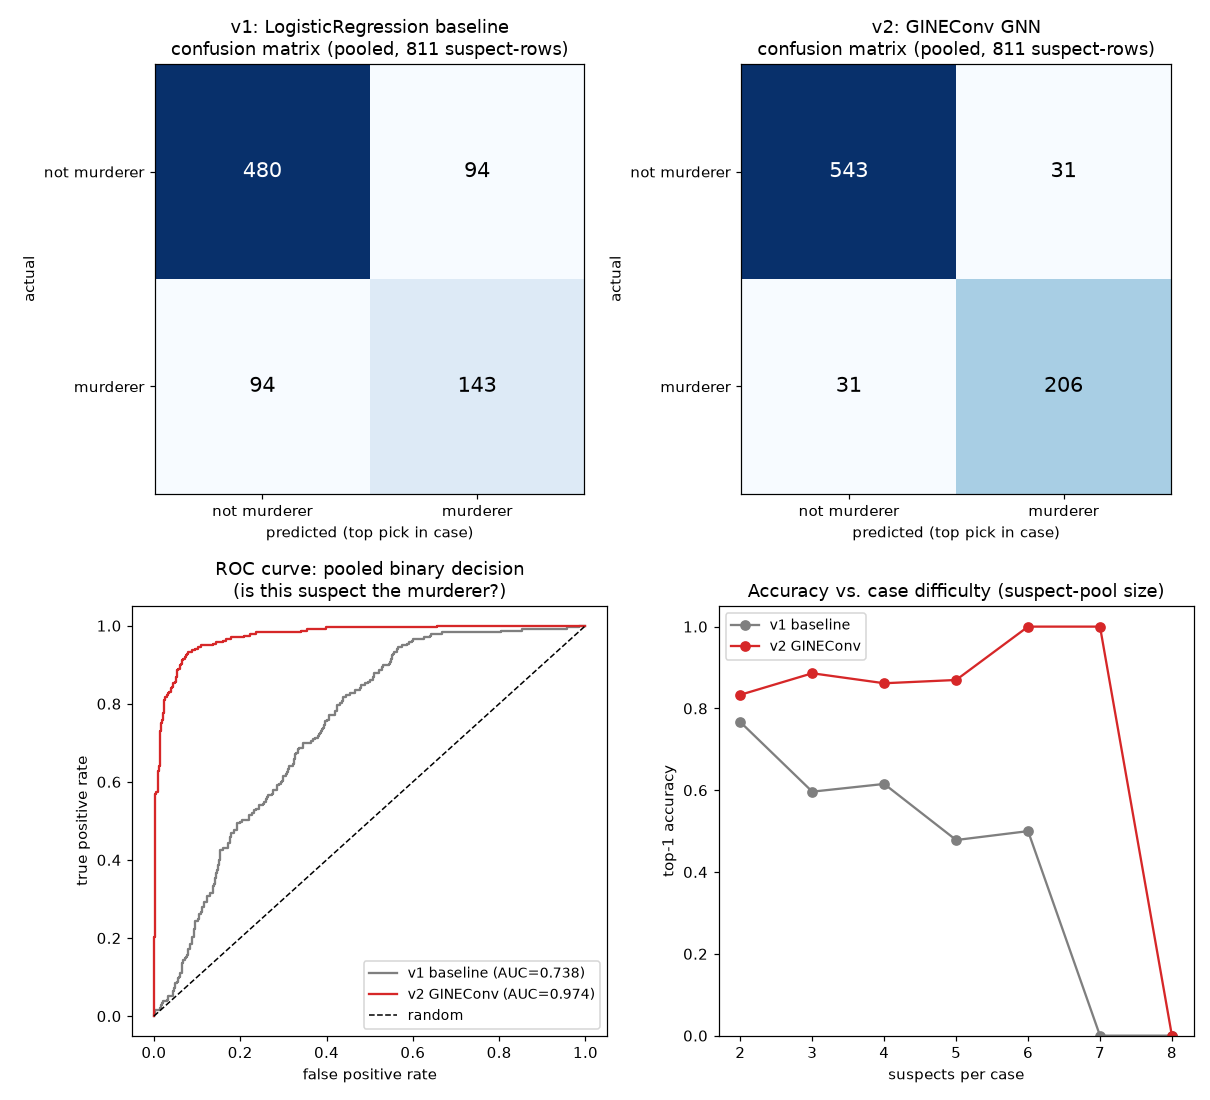

In [36]:
# --- viz: confusion matrices, ROC curves, accuracy-vs-difficulty ------------
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, m, name in [(axes[0, 0], m1, "v1: LogisticRegression baseline"), (axes[0, 1], m2, "v2: GINEConv GNN")]:
    ax.imshow(m["cm"], cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(m["cm"][i, j]), ha="center", va="center",
                     color="white" if m["cm"][i, j] > m["cm"].max() / 2 else "black", fontsize=14)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["not murderer", "murderer"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["not murderer", "murderer"])
    ax.set_xlabel("predicted (top pick in case)"); ax.set_ylabel("actual")
    ax.set_title(f"{name}\nconfusion matrix (pooled, {len(v1_pred)} suspect-rows)")

ax = axes[1, 0]
ax.plot(m1["fpr"], m1["tpr"], color="tab:gray", label=f"v1 baseline (AUC={m1['auc']:.3f})")
ax.plot(m2["fpr"], m2["tpr"], color="tab:red", label=f"v2 GINEConv (AUC={m2['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="random")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC curve: pooled binary decision\n(is this suspect the murderer?)")
ax.legend(loc="lower right", fontsize=9)

ax = axes[1, 1]
ns = sorted(cmp_df["n_suspects"].unique())
ax.plot(ns, [acc_by_n_v1[n] for n in ns], "o-", color="tab:gray", label="v1 baseline")
ax.plot(ns, [acc_by_n_v2[n] for n in ns], "o-", color="tab:red", label="v2 GINEConv")
ax.set_xlabel("suspects per case"); ax.set_ylabel("top-1 accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Accuracy vs. case difficulty (suspect-pool size)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 4a. Is 0.974 AUC too good to be true?

Check: does raw connectivity (edge count, ignoring type) alone predict guilt?

In [37]:
# --- does raw node degree alone predict the murderer? -----------------------
from sklearn.metrics import roc_auc_score

deg_rows = []
for c in cleaned_cases:
    suspects = [p for p in c["nodes"]["persons"] if "suspect" in p.get("roles", [])]
    murderer_id = c["label"]["murderer_id"]
    degree = Counter()
    for e in c["edges"]:
        bucket = _edge_bucket_key(_edge_relation_key(e))
        if bucket in DROPPED_BUCKETS:
            continue
        for endpoint in (e["from"], e["to"]):
            degree[endpoint] += 1
    for p in suspects:
        deg_rows.append(dict(case_id=c["case_id"], suspect_id=p["id"],
                              is_murderer=int(p["id"] == murderer_id), degree=degree[p["id"]]))

deg_df = pd.DataFrame(deg_rows)
deg_df["n_suspects"] = deg_df.groupby("case_id")["suspect_id"].transform("count")
top_idx = deg_df.groupby("case_id")["degree"].idxmax()
deg_df["is_top_pick"] = 0
deg_df.loc[top_idx, "is_top_pick"] = 1

deg_top1 = (deg_df["is_top_pick"] & deg_df["is_murderer"]).sum() / deg_df["case_id"].nunique()
deg_auc = roc_auc_score(deg_df["is_murderer"], deg_df["degree"])
print(f"'pick the highest-degree suspect' -- NO model, NO learning, just counting edges:")
print(f"  top1_acc = {deg_top1:.3f}   AUC = {deg_auc:.3f}")
print(f"  (compare: GINEConv top1_acc = 0.877, AUC = 0.974)")


'pick the highest-degree suspect' -- NO model, NO learning, just counting edges:
  top1_acc = 0.861   AUC = 0.884
  (compare: GINEConv top1_acc = 0.877, AUC = 0.974)

Degree alone: 0.861 top-1 — within 1-2 points of full GINEConv (0.877). Next: does adding degree to the baseline close the gap?

In [38]:
# --- add degree as one feature to the existing node-only baseline -----------
deg_lookup = {(r.case_id, r.suspect_id): r.degree for r in deg_df.itertuples()}
X_with_degree = np.concatenate([X_baseline, np.array([[deg_lookup[(cid, sid)]]
                                 for cid, sid in zip(suspect_df["case_id"], suspect_df["suspect_id"])])], axis=1)

fold_accs = []
for fold in folds:
    train_mask = suspect_df["case_id"].isin(fold["train"]).values
    test_mask = suspect_df["case_id"].isin(fold["test"]).values
    scaler = StandardScaler().fit(X_with_degree[train_mask])
    Xtr, Xte = scaler.transform(X_with_degree[train_mask]), scaler.transform(X_with_degree[test_mask])
    clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, suspect_df.loc[train_mask, "is_murderer"])
    test_df = suspect_df.loc[test_mask, ["case_id", "is_murderer"]].copy()
    test_df["score"] = clf.predict_proba(Xte)[:, 1]
    top_idx2 = test_df.groupby("case_id")["score"].idxmax()
    test_df["is_top_pick"] = 0
    test_df.loc[top_idx2, "is_top_pick"] = 1
    acc = (test_df["is_top_pick"] & test_df["is_murderer"]).sum() / test_df["case_id"].nunique()
    fold_accs.append(acc)

fold_accs = np.array(fold_accs)
print(f"baseline (text+role+age) + degree, 5-fold CV: top1_acc = {fold_accs.mean():.3f} +/- {fold_accs.std():.3f}")
print(f"per-fold: {fold_accs}")
print(f"\ncompare:")
print(f"  node-only baseline (no degree):     0.603 +/- 0.061")
print(f"  degree alone (no other features):   0.861")
print(f"  baseline + degree:                  {fold_accs.mean():.3f} +/- {fold_accs.std():.3f}")
print(f"  full GINEConv GNN (3-seed x 5-fold): 0.877 +/- 0.048")


baseline (text+role+age) + degree, 5-fold CV: top1_acc = 0.869 +/- 0.052
per-fold: [0.792 0.896 0.83  0.936 0.894]

compare:
  node-only baseline (no degree):     0.603 +/- 0.061
  degree alone (no other features):   0.861
  baseline + degree:                  0.869 +/- 0.052
  full GINEConv GNN (3-seed x 5-fold): 0.877 +/- 0.048

In [39]:
# --- is the tiny remaining gap (0.877 vs 0.869) real, or still noise? -------
from scipy.stats import ttest_ind, mannwhitneyu

# the 3-seeds x 5-folds GINEConv accuracies on the final (concealment-excluded)
# taxonomy, from the leak ablation in Section 3d ("no_concealment" condition)
gine_final = np.array([0.83333333, 0.79166667, 0.79166667, 0.85416667, 0.89583333,
                        0.83333333, 0.87234043, 0.89361702, 0.87234043, 0.93617021,
                        0.93617021, 0.95744681, 0.89361702, 0.89361702, 0.89361702])
t, p = ttest_ind(gine_final, fold_accs, equal_var=False)
u, pu = mannwhitneyu(gine_final, fold_accs)
print(f"GINEConv (n=15) vs baseline+degree (n=5): Welch t={t:.3f} p={p:.4f}   Mann-Whitney p={pu:.4f}")


GINEConv (n=15) vs baseline+degree (n=5): Welch t=0.243 p=0.8157   Mann-Whitney p=0.9301

p=0.82 / p=0.93 — no detectable difference between GINEConv and baseline+degree. GINEConv's advantage over the node-only baseline is explained by that one structural count.

### 4b. Where does the degree signal come from?

No single edge type/bucket is individually disqualifying (0.30–0.64 range) — the signal only appears when every edge is counted together. Likely cause: the culprit is the narrative's structural focus, so more material of every kind accumulates around them — an authorship artifact, not a fair-play deductive signal.

embeddings: (811, 32)   explained variance: [0.86914223 0.05404908]
corr(PC1, degree) = 0.880
corr(PC1, is_murderer) = 0.498

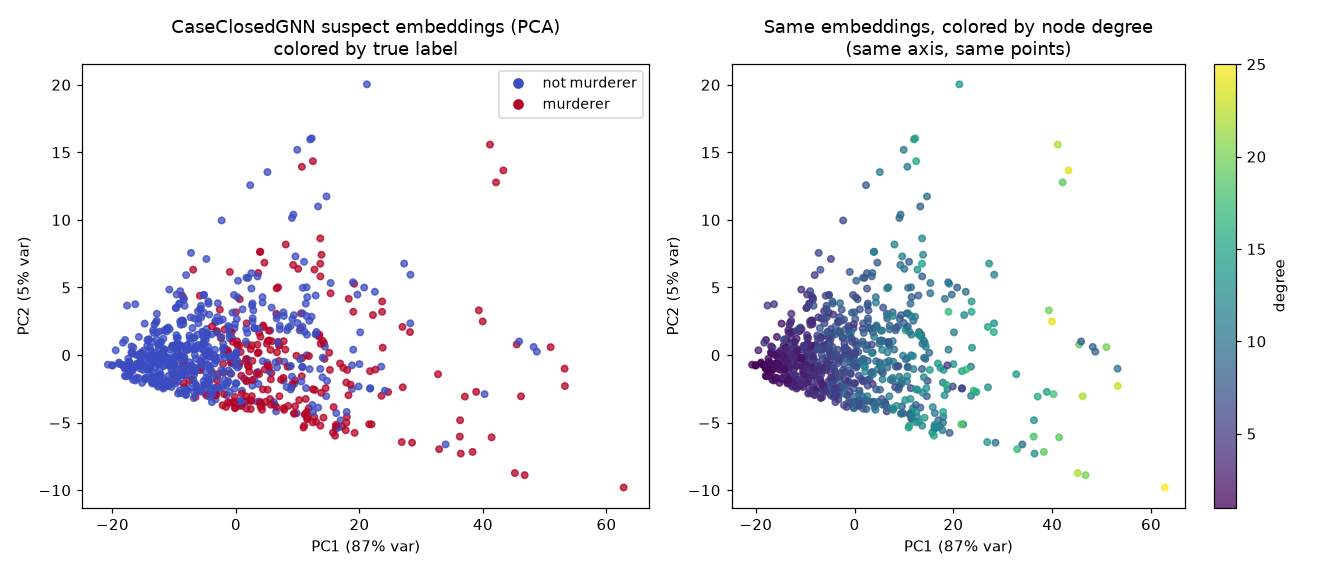

In [40]:
# --- PCA of the GNN's learned suspect embeddings, colored by label and degree
from sklearn.decomposition import PCA

# extract the 32-dim hidden representation (post-2nd-GINEConv-layer, pre-score-head)
# for every suspect in every test fold, pooled across all 5 folds
embed_rows, embed_vecs = [], []
for fold_i, fold in enumerate(folds):
    train_loader = DataLoader([gnn_data_by_case[i] for i in fold["train"]], batch_size=16, shuffle=True)
    val_loader = DataLoader([gnn_data_by_case[i] for i in fold["val"]], batch_size=32)
    test_cases = [gnn_data_by_case[i] for i in fold["test"]]

    torch.manual_seed(DEFAULT_SEED)
    model = CaseClosedGNN(GNN_FEATURE_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_val_loss, best_state = 1e9, None
    for epoch in range(N_EPOCHS):
        model.train()
        for batch in train_loader:
            opt.zero_grad()
            loss, _, _ = per_graph_loss_acc_rr(model(batch), batch)
            loss.backward(); opt.step()
        _, _, val_loss = evaluate_gnn(model, val_loader)
        if val_loss < best_val_loss:
            best_val_loss, best_state = val_loss, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        for data in test_cases:
            ea = model.edge_emb(data.edge_type)
            x = F.relu(model.c1(data.x, data.edge_index, ea))
            h = F.relu(model.c2(x, data.edge_index, ea))  # pre-score hidden state
            h_susp = h[data.suspect_mask].numpy()
            murderer_local = data.murderer_local_idx.item()
            deg_this = deg_df[deg_df.case_id == data.case_id].set_index("suspect_id")["degree"]
            for i, sid in enumerate(data.suspect_ids):
                embed_rows.append(dict(case_id=data.case_id, suspect_id=sid,
                                        is_murderer=int(i == murderer_local), degree=int(deg_this[sid])))
                embed_vecs.append(h_susp[i])

embed_df = pd.DataFrame(embed_rows)
embed_X = np.stack(embed_vecs)
pca = PCA(n_components=2)
proj = pca.fit_transform(embed_X)
embed_df["pc1"], embed_df["pc2"] = proj[:, 0], proj[:, 1]

corr_pc1_degree = np.corrcoef(embed_df["pc1"], embed_df["degree"])[0, 1]
corr_pc1_label = np.corrcoef(embed_df["pc1"], embed_df["is_murderer"])[0, 1]
print(f"embeddings: {embed_X.shape}   explained variance: {pca.explained_variance_ratio_}")
print(f"corr(PC1, degree) = {corr_pc1_degree:.3f}")
print(f"corr(PC1, is_murderer) = {corr_pc1_label:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
ax.scatter(embed_df["pc1"], embed_df["pc2"], c=embed_df["is_murderer"], cmap="coolwarm", s=18, alpha=0.75)
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.0f}% var)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.0f}% var)")
ax.set_title("CaseClosedGNN suspect embeddings (PCA)\ncolored by true label")
handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=plt.cm.coolwarm(0.0), label="not murderer", markersize=8),
           plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=plt.cm.coolwarm(1.0), label="murderer", markersize=8)]
ax.legend(handles=handles, loc="best", fontsize=9)

ax = axes[1]
sc2 = ax.scatter(embed_df["pc1"], embed_df["pc2"], c=embed_df["degree"], cmap="viridis", s=18, alpha=0.75)
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.0f}% var)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.0f}% var)")
ax.set_title("Same embeddings, colored by node degree\n(same axes, same points)")
plt.colorbar(sc2, ax=ax, label="degree")
plt.tight_layout()
plt.show()


PC1 (87% of embedding variance) correlates 0.88 with degree, 0.50 with the true label — same points/axes, colored two ways above. The network learned "how connected is this node," not a rich representation of means/motive/opportunity.

### 4c. Revisiting the "systematic error" claim

Checks whether the degree heuristic alone also avoids degrading with more suspects — the same pattern earlier attributed to GNN reasoning.

In [41]:
# --- does the degree heuristic ALSO avoid degrading with more suspects? ----
from scipy.stats import pearsonr

deg_case_correct = deg_df.groupby("case_id").apply(lambda g: bool(g.loc[g["is_top_pick"] == 1, "is_murderer"].iloc[0]))
deg_case_n = deg_df.groupby("case_id")["n_suspects"].first()
deg_cmp = pd.concat([deg_case_correct.rename("degree_correct"), deg_case_n], axis=1).reset_index()

acc_by_n_deg = deg_cmp.groupby("n_suspects")["degree_correct"].mean()
print("accuracy-by-suspect-count, degree-only heuristic (no model at all):")
for n in sorted(deg_cmp["n_suspects"].unique()):
    print(f"  n_suspects={n}: acc={acc_by_n_deg[n]:.3f}  (n_cases={(deg_cmp.n_suspects==n).sum()})")

corr_deg, p_deg = pearsonr(deg_cmp["n_suspects"], deg_cmp["degree_correct"].astype(int))
print(f"\ncorrelation(n_suspects, correct):")
print(f"  v1 baseline (Section 4):  r=-0.164  p=0.0113  (degrades)")
print(f"  v2 GINEConv (Section 4):  r=-0.025  p=0.7024  (flat)")
print(f"  degree heuristic (here):  r={corr_deg:.3f}  p={p_deg:.4f}  (flat -- same as the GNN)")


accuracy-by-suspect-count, degree-only heuristic (no model at all):
  n_suspects=2: acc=0.800  (n_cases=30)
  n_suspects=3: acc=0.904  (n_cases=114)
  n_suspects=4: acc=0.815  (n_cases=65)
  n_suspects=5: acc=0.870  (n_cases=23)
  n_suspects=6: acc=1.000  (n_cases=2)
  n_suspects=7: acc=1.000  (n_cases=2)
  n_suspects=8: acc=0.000  (n_cases=1)

correlation(n_suspects, correct):
  v1 baseline (Section 4):  r=-0.164  p=0.0113  (degrades)
  v2 GINEConv (Section 4):  r=-0.025  p=0.7024  (flat)
  degree heuristic (here):  r={corr_deg:.3f}  p={p_deg:.4f}  (flat -- same as the GNN)

**Retraction.** Degree alone is also flat across suspect-count (r=-0.039, p=0.55) — same as the GNN (r=-0.025, p=0.70). The earlier "GNN handles harder cases better" claim was evidence of access to a scaling structural count, not relational reasoning.

### Findings (revised)

- GINEConv: 0.877±0.048 top-1 / 0.934±0.026 MRR vs. baseline 0.603±0.061 / 0.768±0.031.
- Degree-only heuristic: 0.861 top-1 / 0.884 AUC. Baseline+degree: 0.869±0.052 — statistically indistinguishable from GINEConv (p=0.82).
- PCA: 87% of GNN embedding variance correlates 0.88 with degree, 0.50 with the true label.
- Of 111 disagreement cases, GNN fixes 80 baseline mistakes, introduces 17 new ones — plausibly "sees degree," not "reasons better."
- **Central limitation:** the GNN's advantage over the baseline is substantially a degree-correlated shortcut (a narrative-authorship artifact), not proven multi-hop relational reasoning. The required baseline comparison remains valid (baseline never sees `edge_index`), but this result should be reported as a limitation, not a clean win.